# Refine T-cell states in the AL bone marrow

**Biology rationale.** T-cell subtype resolution is required to evaluate cytotoxic, regulatory, and interferon-associated responses in the plasma-cell niche.

**Aim.** Subset and annotate T-cell populations and quantify their clinical and transcriptional differences.

**Data input.** `sce1_Tcell.rds`, `sce1_tcell.h5ad`, `STAR_adata_obs.tsv`, `FigS11c.pdf`, `FigS11d.pdf`



**Data outputs.** `ALL_boxplots_by_celltype_good_poor.pdf`, `saved_plot_files.csv`, `ALL_boxplots_by_celltype_pre_post_genes_columns_groups_rows.pdf`

## 1. Packages and setup


In [1]:
library(Seurat)
library(patchwork)
library(speckle)
library(limma)
library(ggplot2)
library(DropletUtils)
library(Matrix)
library(celda)
library(SingleCellExperiment)
library(SingleR)
library(celldex)
library(scCustomize)
library(dplyr)
library(tidyr)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t






Loading required package: SingleCellExperiment

Loading required package: SummarizedExperiment

Loading required package: MatrixGenerics

Loading required package: matrixStats


Attaching package: ‘MatrixGenerics’


The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeightedVars, rowAlls, rowAnyNAs, rowAnys, rowAvgsPerColSet,
    rowCollaps

In [2]:
# Set these *before* library(reticulate) or library(sceasy)
Sys.setenv(RETICULATE_PYTHON = "/home/miniconda3/envs/carlin/bin/python")
options(reticulate.conda_binary = "/home/miniconda3/bin/conda")

library(reticulate)
py_config()  # should now show your conda 'jupyter' Python


python:         /home/miniconda3/envs/carlin/bin/python
libpython:      /home/miniconda3/envs/carlin/lib/libpython3.8.so
pythonhome:     /home/miniconda3/envs/carlin:/home/miniconda3/envs/carlin
version:        3.8.19 | packaged by conda-forge | (default, Mar 20 2024, 12:47:35)  [GCC 12.3.0]
numpy:          /home/miniconda3/envs/carlin/lib/python3.8/site-packages/numpy
numpy_version:  1.24.4

NOTE: Python version was forced by RETICULATE_PYTHON

In [3]:
sce1_tcell<-readRDS(file='sce1_Tcell.rds')

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”


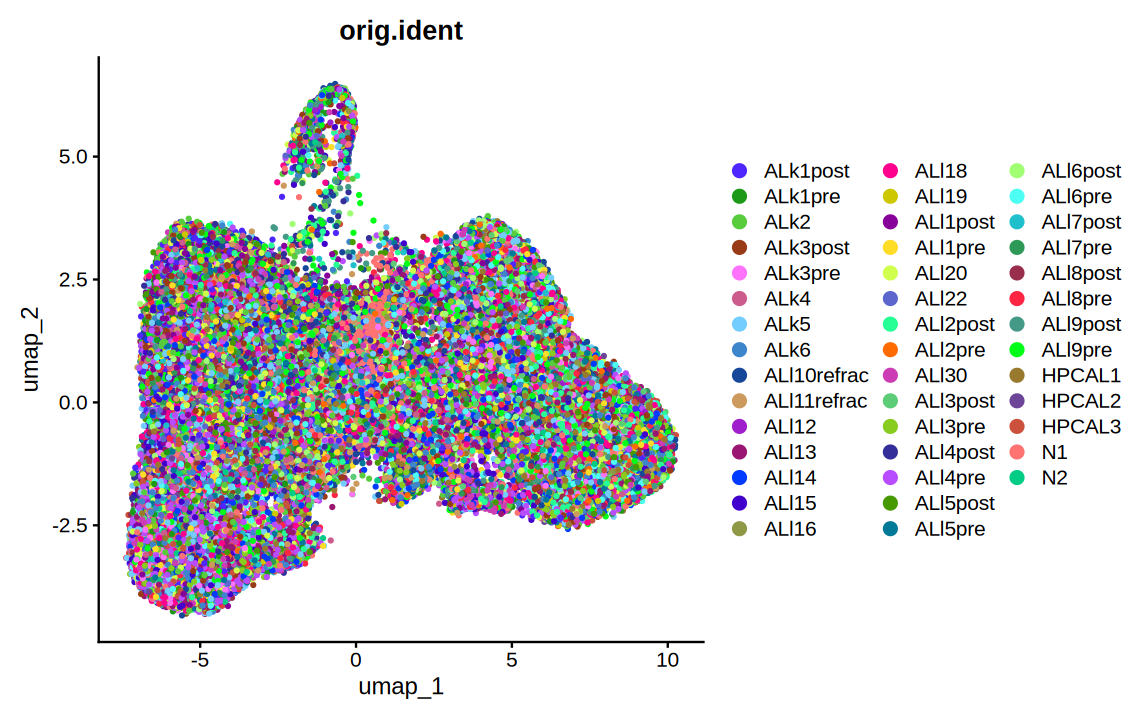

In [4]:
library(scCustomize)
options(repr.plot.height=6,repr.plot.width=9.5)
DimPlot_scCustom(sce1_tcell, pt.size=0.5,reduction = "umap", group.by = c("orig.ident"),label=F) 

In [5]:
library(Seurat)
library(sceasy)

# Subset both groups together in one step
subset_cells <- sce1_tcell

# Ensure RNA assay is properly formatted
subset_cells[["RNA"]] <- as(subset_cells[["RNA"]], "Assay")

# Save as .h5ad
sceasy::convertFormat(subset_cells, from = "seurat", to = "anndata", outFile = "sce1_tcell.h5ad")


Warning message:
“Assay RNA changing from Assay5 to Assay”
Warning message in .regularise_df(obj@meta.data, drop_single_values = drop_single_values):
“Dropping single category variables:singlet, Nover.lineage”


AnnData object with n_obs × n_vars = 135109 × 36601
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'percent.ig', 'percent.hb', 'unintegrated_clusters', 'seurat_clusters', 'barcode', 'Nover', 'harmony_clusters'
    var: 'vf_vst_counts_mean', 'vf_vst_counts_variance', 'vf_vst_counts_variance.expected', 'vf_vst_counts_variance.standardized', 'vf_vst_counts_variable', 'vf_vst_counts_rank', 'var.features', 'var.features.rank'
    obsm: 'X_pca', 'X_umap', 'X_harmony'

## 2. Cell-type annotation


In [6]:
library(readr)
library(dplyr)

# Read the AnnData obs (first column = cell_id)
obs <- read.delim("STAR_adata_obs.tsv", row.names = 1, check.names = FALSE)

# Keep only cells present in the sce1_tcellrat object, in the right order
obs <- obs[Cells(sce1_tcell), , drop = FALSE]

# Attach to sce1_tcellrat (row names of obs must be cell IDs)
sce1_tcell <- AddMetaData(sce1_tcell, metadata = obs)

# Quick check: same number of rows as cells?
stopifnot(nrow(sce1_tcell@meta.data) == length(Cells(sce1_tcell)))



In [7]:
# Make a new column 'final_label':
lab0 <- as.character(sce1_tcell$Nover)
mlab <- as.character(sce1_tcell$Multinomial_Label)

# Rule: if original label == "TT" -> "NPT"; otherwise use Multinomial_Label
final <- ifelse(!is.na(lab0) & lab0 == "T T cells","T T cells", mlab)

# Optional fallback: if Multinomial_Label is NA/blaT, fall back to original label
final[is.na(final) | final == ""] <- lab0[is.na(final) | final == ""]

# Save (as factor with stable levels)
sce1_tcell$final_label <- factor(final, levels = sort(unique(final)))


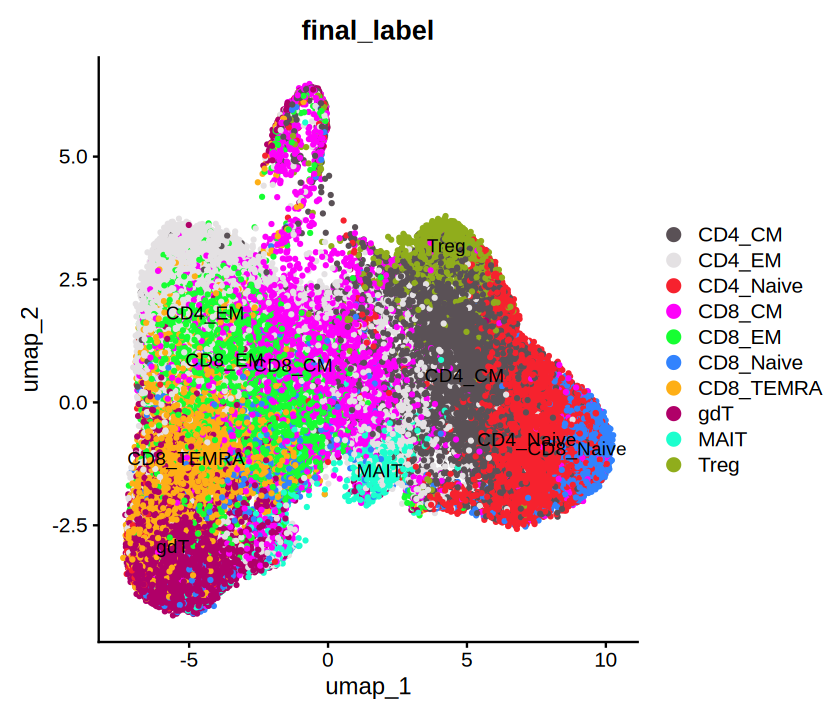

In [8]:
library(scCustomize)
options(repr.plot.height=6,repr.plot.width=7)
DimPlot_scCustom(sce1_tcell, pt.size=0.5,reduction = "umap", group.by = c("final_label"),label=T) 

## 3. Visualization and figure generation


In [9]:
p <- DimPlot_scCustom(sce1_tcell, pt.size=0.5,reduction = "umap", group.by = c("final_label"),label=T)  
ggsave("FigS11c.pdf", plot = p, width = 7, height =6)


In [10]:
Idents(sce1_tcell)<-'final_label'

# Create a custom blue to yellow color palette
blue_red_palette <- colorRampPalette(c("steelblue", "white", "firebrick"))

# Define a color vector with 26 colors
cols_vec <- colorRampPalette(c("steelblue", "white", "firebrick"))(26)

# cytotoxicity, exhaustion, activation, and cytokine-dependent

# all marker
allgene<- c(
  # CD8+ Effector T cells
  "CD8A", "GZMB", "IFNG", "TNF",
  ## CD4+ 
  "CD4", "CD40LG",
  ## Tregs
  "FOXP3", "IL2RA", "CTLA4",
  ## Th1 cells
  "TBX21", "IFNG",
  ## Th2 cells
  "GATA3", "IL4", "IL5", "IL13",
  #3 Th17 cells
  "RORC", "IL17A",
  ## T follicular helper (Tfh) cells
  "BCL6", "CXCR5", "ICOS",
  # CD8+ Memory-like / Progenitor exhausted
  "TCF7", "IL7R", "SELL",
  # CD8+ Exhausted T cells (Tex)
  "PDCD1", "LAG3", "TIGIT", "HAVCR2", "CTLA4",
  "CD38"
)



In [11]:
library(RColorBrewer)

# Define a color vector with 26 colors
cols_vec <- colorRampPalette(c("steelblue", "white", "firebrick"))(26)

# Use DotPlot with the color palette

# Re-run DotPlot with deduplicated genes
initial_plot <- DotPlot(sce1_tcell, features = unique(allgene),  scale = TRUE, cols = cols_vec)

# Extract and plot
plot_data <- initial_plot$data



Attaching package: ‘reshape2’


The following object is masked from ‘package:tidyr’:

    smiths




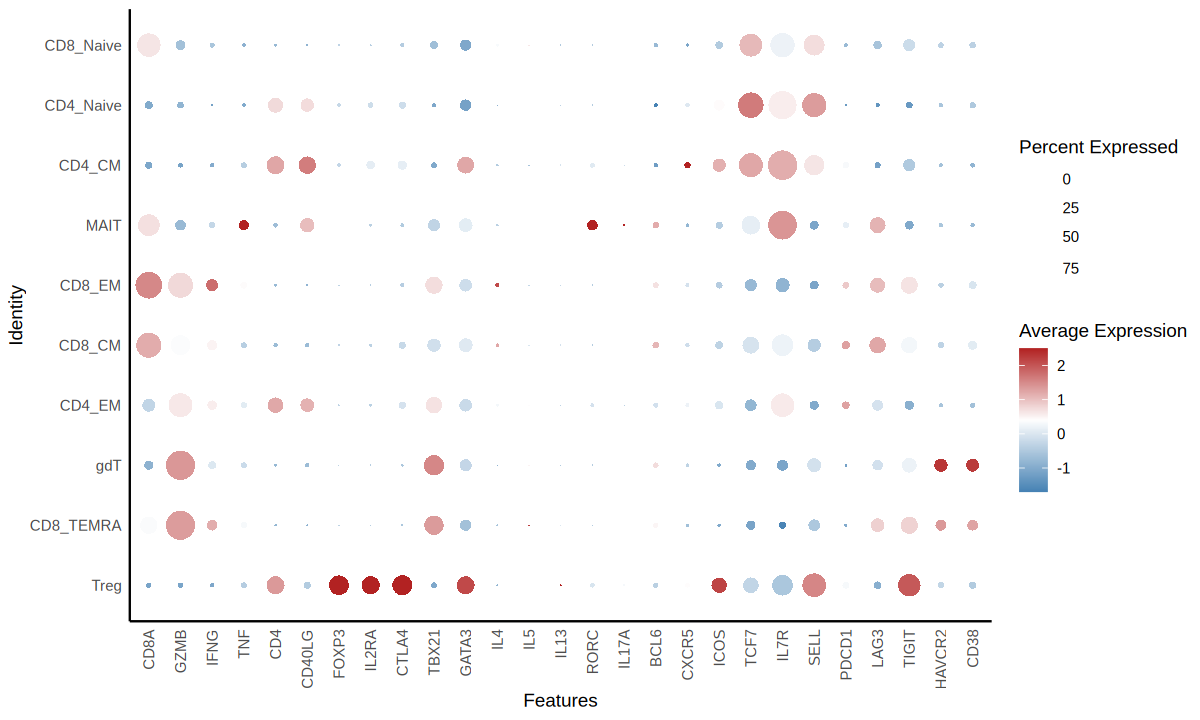

In [12]:
options(repr.plot.height=6,repr.plot.width=10)
library(pheatmap)  # For clustering
library(reshape2)  # For reshaping

# Pivot the data to get matrix for clustering (avg.exp.scaled by id and feature)
mat <- reshape2::dcast(plot_data, id ~ features.plot, value.var = "avg.exp.scaled")
rownames(mat) <- mat$id
mat$id <- NULL

# Hierarchical clustering of ids (rows)
clust <- hclust(dist(mat))
new_order <- clust$labels[clust$order]  # ordered row names

# Reorder the id factor in plot_data
plot_data$id <- factor(plot_data$id, levels = new_order)

# Rebuild the plot
p <- ggplot(plot_data, aes(x = features.plot, y = id)) +
  geom_point(aes(size = pct.exp, fill = avg.exp.scaled), shape = 21, color = "black", stroke = 0) +
  scale_size(range = c(0, 8), name = "Percent Expressed") +
  scale_fill_gradientn(colors = blue_red_palette(100), name = "Average Expression") +
  theme_minimal() +
  theme(
    axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    panel.background = element_blank(),
    axis.line = element_line(color = "black")
  ) +
  labs(x = "Features", y = "Identity")

p


In [13]:
ggsave("FigS11d.pdf", plot = p, width = 7, height =6)

## 4. Sample metadata and clinical groups


In [14]:
sce1_tcell$label <- sce1_tcell$orig.ident
sce1_tcell$label <- ifelse(grepl("N1|N2", sce1_tcell$label), "Normal", sce1_tcell$label)
sce1_tcell$label <- ifelse(grepl("ALl9pre|ALl8pre|ALl6pre|ALl30|ALl20|ALl19|ALl18|ALl14|ALl13|ALl1pre|ALk4|ALk1pre", sce1_tcell$label), "AL_CR_pre", sce1_tcell$label)
sce1_tcell$label <- ifelse(grepl("ALl9post|ALl8post|ALl6post|ALl1post|ALk1post", sce1_tcell$label), "AL_CR_post", sce1_tcell$label)
sce1_tcell$label <- ifelse(grepl("ALl3pre|ALl22|ALk3pre|ALk2|HPCAL2", sce1_tcell$label), "AL_VGPR_pre", sce1_tcell$label)
sce1_tcell$label <- ifelse(grepl("ALk3post|ALl3post", sce1_tcell$label), "AL_VGPR_post", sce1_tcell$label)
sce1_tcell$label <- ifelse(grepl("ALl7pre|ALl12|ALk6|HPCAL1", sce1_tcell$label), "AL_NR/SD_pre", sce1_tcell$label)
sce1_tcell$label <- ifelse(grepl("ALl7post", sce1_tcell$label), "AL_NR/SD_post", sce1_tcell$label)
sce1_tcell$label <- ifelse(grepl("ALl5pre|ALl4pre|ALl2pre|ALl16", sce1_tcell$label), "AL_PR_pre", sce1_tcell$label)
sce1_tcell$label <- ifelse(grepl("ALl5post|ALl4post|ALl2post|ALl11refrac|ALl10refrac", sce1_tcell$label), "AL_PR_post", sce1_tcell$label)
sce1_tcell$label <- ifelse(grepl("HPCAL3|ALl15|ALk5", sce1_tcell$label), "AL_NotRecorded", sce1_tcell$label)

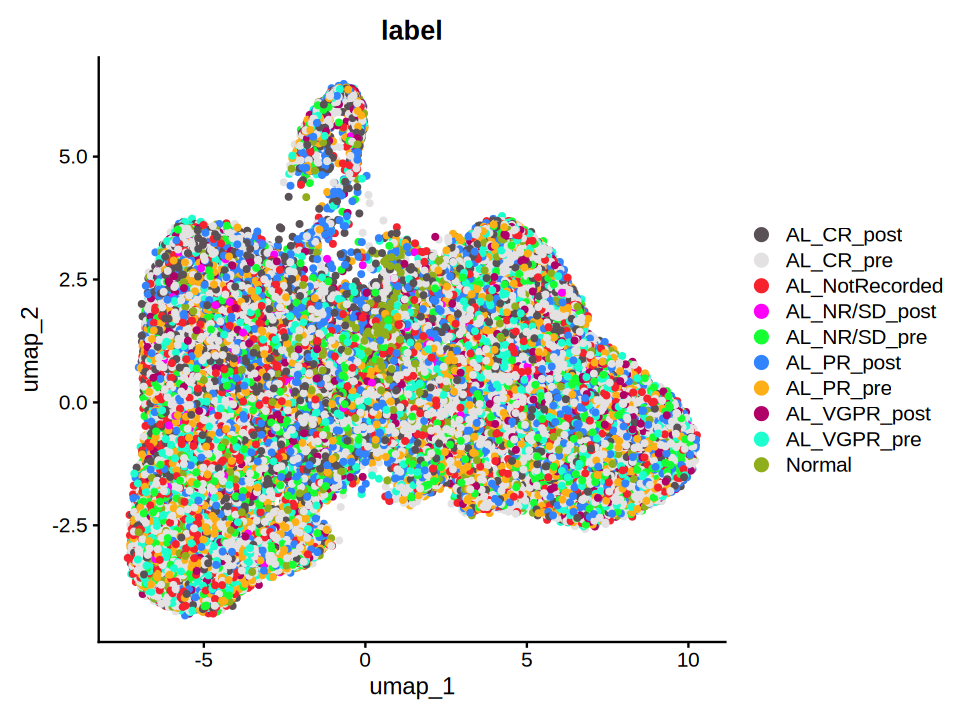

In [15]:
library(scCustomize)
options(repr.plot.height=6,repr.plot.width=8)
DimPlot_scCustom(sce1_tcell , pt.size=1,reduction = "umap", group.by = c("label"),label=F) 


Attaching package: ‘scales’


The following object is masked from ‘package:readr’:

    col_factor


# mismatched Pre:  0

# mismatched Post: 0



# A tibble: 60 × 6
   response celltype    pre  post      pval      padj
   <fct>    <fct>     <int> <int>     <dbl>     <dbl>
 1 AL_CR    CD4_CM     6450  1624 0         0        
 2 AL_CR    CD4_Naive  7306  1255 0         0        
 3 AL_CR    CD8_TEMRA  4819   986 0         0        
 4 AL_CR    gdT        4252   350 0         0        
 5 AL_NR/SD CD4_Naive  1982    56 0         0        
 6 AL_NR/SD CD8_TEMRA  2327    26 0         0        
 7 AL_VGPR  CD8_TEMRA  2588   520 3.44e-301 1.97e-300
 8 AL_NR/SD CD4_CM     1508   115 5.53e-262 2.77e-261
 9 AL_CR    CD4_EM     6223  2964 2.12e-253 9.42e-253
10 AL_CR    CD8_Naive  2309   568 4.11e-231 1.64e-230
11 AL_NR/SD gdT        1074    23 5.60e-221 2.04e-220
12 AL_PR    gdT        1974   489 1.01e-196 3.37e-196
13 AL_NR/SD CD8_Naive   764     7 1.18e-163 3.62e-163
14 AL_PR    CD8_TEMRA  1975   616 4.91e-157 1.40e-156
15 AL_VGPR  gdT        1422   317 1.02e-154 2.73e-154
16 AL_CR    CD8_EM     5394  3015 2.17e-148 5.44e-148
17 AL_CR 

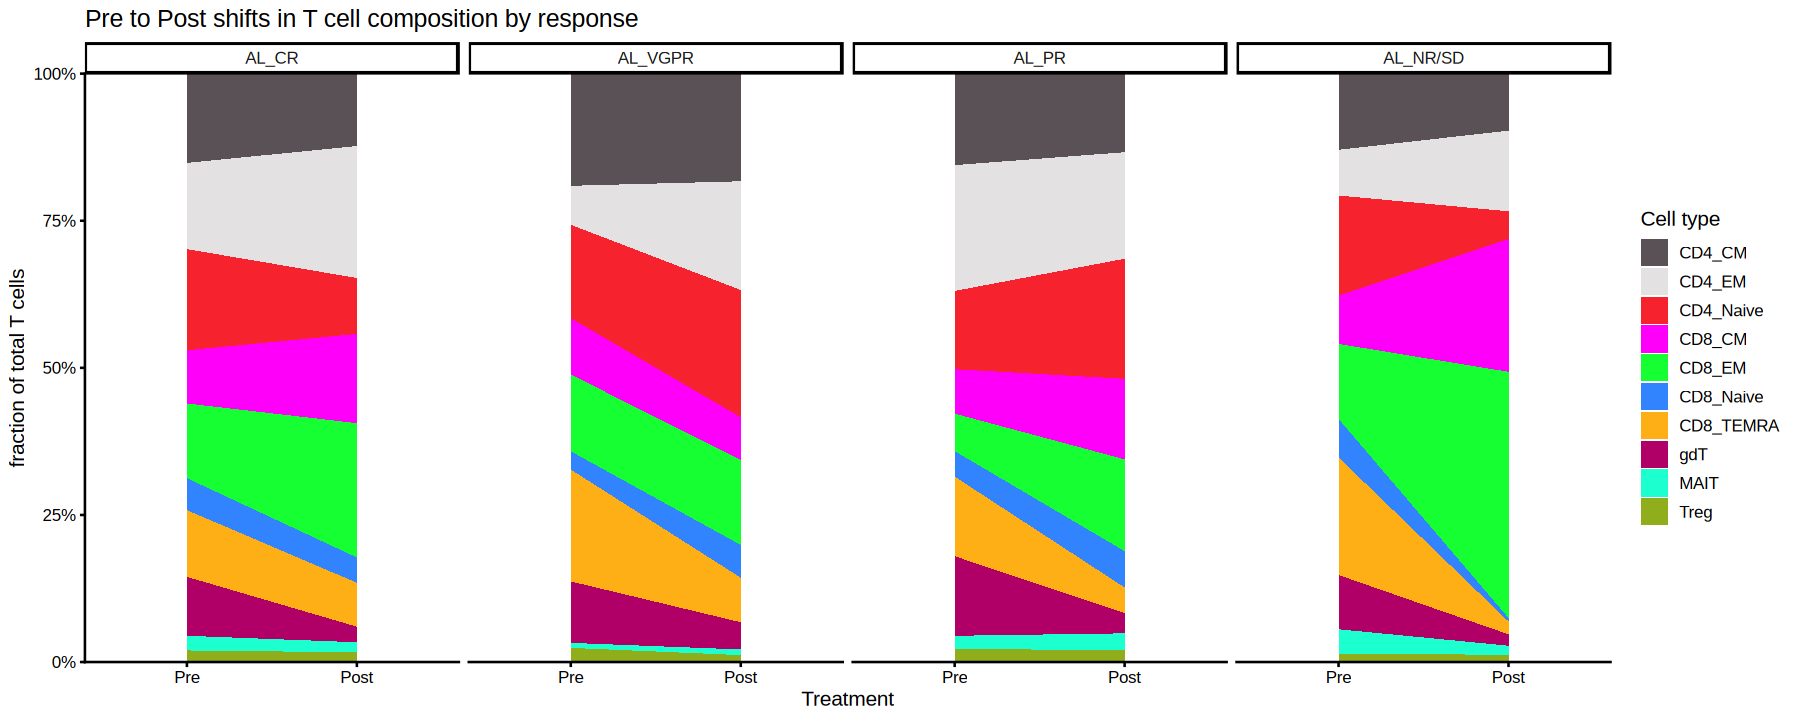

In [16]:
library(dplyr)
library(tidyr)
library(ggplot2)
library(scales)
library(scCustomize)

sce1_tcell@meta.data$Annotation<-sce1_tcell@meta.data$"final_label"
Idents(sce1_tcell) <- "final_label"
ct_lvls <- levels(sce1_tcell)
ct_cols <- setNames(
  scCustomize::DiscretePalette_scCustomize(length(ct_lvls), palette = "polychrome"),
  ct_lvls
)

# --- 0) Clean the label column (quotes, spaces, smart quotes) ---
sce1_tcell$label <- as.character(sce1_tcell$label)
sce1_tcell$label <- gsub("[[:space:]'‘’\"“”]", "", sce1_tcell$label)

# --- 1) Build md with anchored matching ---
md <- sce1_tcell@meta.data %>%
  as.data.frame() %>%
  mutate(
    label_clean = gsub("[[:space:]'‘’\"“”]", "", label)  # defensive
  ) %>%
  transmute(
    celltype  = Annotation,
    response  = sub("_(pre|post)$", "", label_clean, perl = TRUE),
    treatment = case_when(
      grepl("(_pre)$",  label_clean, perl = TRUE) ~ "Pre",
      grepl("(_post)$", label_clean, perl = TRUE) ~ "Post",
      TRUE ~ "Other"
    ),
    label_clean = label_clean
  )

# --- 2) Sanity checks ---
# Any cells flagged as Pre that do NOT end with _pre ?
bad_pre  <- md %>% filter(treatment == "Pre"  & !grepl("(_pre)$",  label_clean, perl = TRUE))
bad_post <- md %>% filter(treatment == "Post" & !grepl("(_post)$", label_clean, perl = TRUE))
message("# mismatched Pre:  ", nrow(bad_pre))
message("# mismatched Post: ", nrow(bad_post))
# If you see non-zero here, print some examples:
if (nrow(bad_pre) > 0 || nrow(bad_post) > 0) {
  print(head(unique(c(bad_pre$label_clean, bad_post$label_clean)), 10))
}

# --- 3) Composition per response × treatment (as before) ---
comp <- md %>%
  count(response, treatment, celltype, name = "n") %>%
  group_by(response, treatment) %>%
  mutate(frac = n / sum(n)) %>%
  ungroup() %>%
  complete(response, treatment, celltype, fill = list(n = 0, frac = 0))

comp$celltype  <- factor(comp$celltype,  levels = ct_lvls)
comp$treatment <- factor(comp$treatment, levels = c("Pre","Post","Other"))

# --- 4) Plot (skip Normal and AL_NotRecorded only in the plot) ---
options(repr.plot.height = 6, repr.plot.width = 15)

# Force the facet order
comp$response <- factor(comp$response,
                        levels = c("AL_CR", "AL_VGPR", "AL_PR", "AL_NR/SD","AL_NotRecorded","Normal"))

p <- ggplot(
  comp %>%
    filter(treatment %in% c("Pre", "Post"),
           !response %in% c("Normal", "AL_NotRecorded")),
  aes(x = treatment, y = frac, fill = celltype, group = celltype)
) +
  geom_area(stat = "identity", position = "stack") +
  facet_wrap(~response, nrow = 1) +   # one row, fixed order
  scale_y_continuous(labels = percent_format(accuracy = 1), expand = c(0,0)) +
  labs(y = "fraction of total T cells", x = "Treatment", fill = "Cell type",
       title = "Pre to Post shifts in T cell composition by response") +
  scale_fill_manual(values = ct_cols) +
  theme_classic(base_size = 12) +
  theme(panel.grid.minor = element_blank(),
        legend.position = "right")

print(p)



# --- 5) Stats (unchanged) ---
chisq_results <- comp %>%
  filter(treatment %in% c("Pre","Post")) %>%
  group_by(response, celltype) %>%
  summarise(
    pre  = sum(n[treatment == "Pre"]),
    post = sum(n[treatment == "Post"]),
    .groups="drop"
  ) %>%
  rowwise() %>%
  mutate(pval = ifelse((pre+post) > 0,
                       chisq.test(c(pre, post), p = c(0.5, 0.5))$p.value,
                       NA_real_)) %>%
  ungroup() %>%
  mutate(padj = p.adjust(pval, method="BH")) %>%
  arrange(padj)

chisq_results %>% print(n = 20)


## 5. Clean labels and derive response/treatment per cell (anchored)


In [17]:
# 0) Clean labels and derive response/treatment per cell (anchored)
sce1_tcell$label <- as.character(sce1_tcell$label)
sce1_tcell$label <- gsub("[[:space:]'‘’\"“”]", "", sce1_tcell$label)

meta_df <- sce1_tcell@meta.data %>%
  as.data.frame() %>%
  mutate(
    label_clean = gsub("[[:space:]'‘’\"“”]", "", label),
    response  = sub("_(pre|post)$", "", label_clean, perl = TRUE),
    treatment = case_when(
      grepl("(_pre)$",  label_clean, perl = TRUE) ~ "Pre",
      grepl("(_post)$", label_clean, perl = TRUE) ~ "Post",
      TRUE ~ NA_character_
    ),
    celltype  = Annotation
  )


# Attach for convenience
sce1_tcell$response  <- meta_df$response
sce1_tcell$treatment <- meta_df$treatment


In [18]:
sce1_tcell@meta.data$barcode<-rownames(sce1_tcell@meta.data)
label<-sce1_tcell@meta.data[,c('barcode','final_label')]
write.csv(label,file='Tcell.noverlabel.csv')

In [19]:
# 1) Keep only valid Pre/Post cells for expression averaging
valid <- with(meta_df, !is.na(response) & !is.na(treatment))
sce_expr <- subset(sce1_tcell, cells = rownames(meta_df)[valid])

# 2) Define markers (gene symbols in RNA assay)
marker_map <- c(
  LAG3   = "LAG3",
  TIGIT  = "TIGIT",
  HAVCR2 = "HAVCR2",
  CTLA4  = "CTLA4",
  PDCD1  = "PDCD1")
features_to_use <- unique(unname(marker_map))
features_present <- features_to_use[features_to_use %in% rownames(sce_expr)]
if (length(features_present) == 0) stop("None of the marker genes are present in the object.")

# 3) Build grouping key for averaging: response|treatment|celltype
sce_expr$resp_treat_ct <- with(sce_expr@meta.data, paste(response, treatment, Annotation, sep = "|"))



In [20]:
avg <- AverageExpression(
  sce_expr,
  features = features_present,
  group.by = "resp_treat_ct",
  assays = "RNA",
  slot = "data"
)$RNA
# rows = genes, cols = "response|treatment|celltype"


As of Seurat v5, we recommend using AggregateExpression to perform pseudo-bulk analysis.
This message is displayed once per session.
Names of identity class contain underscores ('_'), replacing with dashes ('-')
This message is displayed once every 8 hours.


In [21]:
# 4) Tidy to long + map gene -> marker
df_expr <- as.data.frame(avg) %>%
  tibble::rownames_to_column("gene") %>%
  pivot_longer(-gene, names_to = "grp", values_to = "expr") %>%
  separate(grp, into = c("response","treatment","celltype"), sep = "\\|", fill = "right") %>%
  filter(!is.na(response), !is.na(treatment), !is.na(celltype)) %>%
  mutate(marker = names(marker_map)[match(gene, marker_map[marker_map %in% gene])]) %>%
  filter(!is.na(marker))

## 6. Sample metadata and clinical groups


In [22]:
# 5) Prepare diverging values (Pre negative, Post positive) + response grouping
df_plot <- df_expr %>%
  mutate(
    response  = factor(response, levels = c("AL-CR","AL-VGPR","AL-PR","AL-NR/SD")),
    treatment = factor(treatment, levels = c("Pre","Post")),
    celltype  = celltype,
    value     = ifelse(treatment == "Post", expr, -expr),
    response_group = case_when(
      response %in% c("AL-CR","AL-VGPR")   ~ "Good",
      response %in% c("AL-PR","AL-NR/SD")  ~ "Poor",
      TRUE ~ NA_character_
    )
  ) %>%
  # Omit anything not mapped (e.g., Normal / AL_NotRecorded) only in the plot
  filter(!is.na(response_group)) %>%
  mutate(response_group = factor(response_group, levels = c("Good","Poor")))

# Labels for the grouped facet
grp_labeller <- as_labeller(c(Good = "Good (CR + VGPR)", Poor = "Poor (PR + NR/SD)"))

options(repr.plot.height = 10, repr.plot.width = 8)



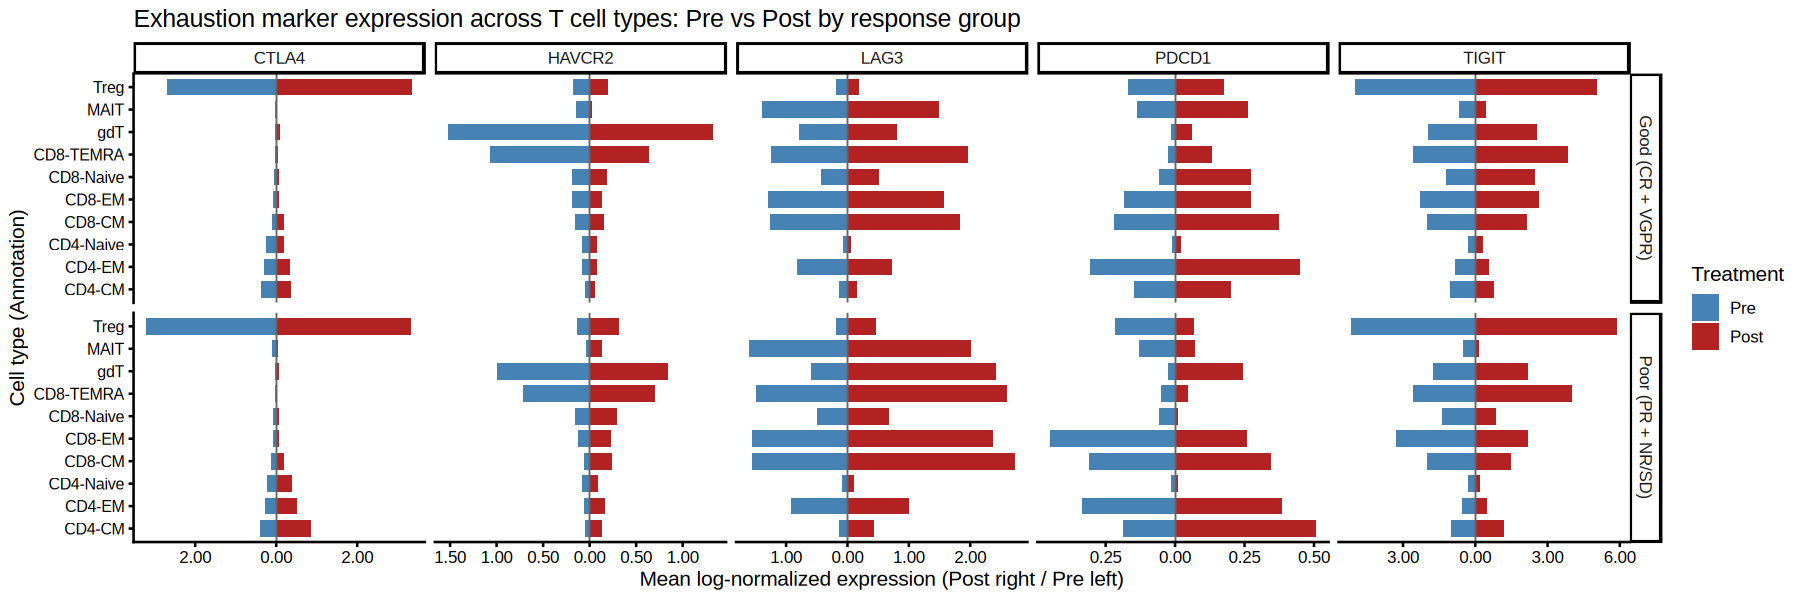

In [23]:
# Group responses (CR/VGPR -> Good; PR/NR/SD -> Poor)
df_plot <- df_expr %>%
  mutate(
    response  = factor(response, levels = c("AL-CR","AL-VGPR","AL-PR","AL-NR/SD")),
    treatment = factor(treatment, levels = c("Pre","Post")),
    value     = ifelse(treatment == "Post", expr, -expr),
    response_group = case_when(
      response %in% c("AL-CR","AL-VGPR")  ~ "Good",
      response %in% c("AL-PR","AL-NR/SD") ~ "Poor",
      TRUE ~ NA_character_
    )
  ) %>%
  filter(!is.na(response_group)) %>%
  mutate(response_group = factor(response_group, levels = c("Good","Poor")))

grp_labeller <- as_labeller(c(Good = "Good (CR + VGPR)", Poor = "Poor (PR + NR/SD)"))

options(repr.plot.height = 5, repr.plot.width = 15)

p_diverge <- ggplot(df_plot, aes(x = celltype, y = value, fill = treatment)) +
  geom_col(width = 0.7) +
  geom_hline(yintercept = 0, linewidth = 0.4, color = "grey40") +
  coord_flip() +
  facet_grid(
    rows = vars(response_group),  # <-- Good/Poor as rows
    cols = vars(marker),          # <-- markers as columns
    labeller = labeller(response_group = grp_labeller),
    scales = "free_x"
  ) +
  scale_y_continuous(labels = function(x) sprintf("%.2f", abs(x))) +
  scale_fill_manual(values = c("Pre" = "steelblue", "Post" = "firebrick")) +
  labs(
    x = "Cell type (Annotation)",
    y = "Mean log-normalized expression (Post right / Pre left)",
    fill = "Treatment",
    title = "Exhaustion marker expression across T cell types: Pre vs Post by response group"
  ) +
  theme_classic(base_size = 12) +
  theme(
    panel.grid.minor = element_blank(),
    axis.text.y = element_text(size = 9),
    legend.position = "right"
  )

print(p_diverge)


In [24]:
ggsave("Fig6j.pdf", plot = p_diverge, width = 15, height =5)


## 7. Summarize by Pre vs Post


In [25]:
# Summarize by Pre vs Post
df_summary <- df_expr %>%
  group_by(response, celltype, marker, treatment) %>%
  summarise(mean_expr = mean(expr, na.rm = TRUE), .groups = "drop") %>%
  pivot_wider(names_from = treatment, values_from = mean_expr) %>%
  mutate(
    log2FC = log2((Post + 1e-6) / (Pre + 1e-6))   # add small offset to avoid division by 0
  ) %>%
  filter(!response %in% c("Normal","AL_NotRecorded"))


In [26]:
library(tibble)

options(repr.plot.height=10,repr.plot.width=15)

# 1. Extract metadata
meta <- sce1_tcell@meta.data

# 2. Define the features and the group
features <- colnames(sce1_tcell@meta.data)[14:69]

# 3. Calculate average per `orig.ident`
avg_mat <- meta %>%
  group_by(orig.ident) %>%
  summarise(across(all_of(features), mean, na.rm = TRUE)) %>%
  column_to_rownames("orig.ident") %>%
  t()  # Transpose to get features as rows and orig.ident as columns


Warning message:
“There were 87 warnings in `summarise()`.
The first warning was:
ℹ In argument: `across(all_of(features), mean, na.rm = TRUE)`.
ℹ In group 1: `orig.ident = "ALk1post"`.
Caused by warning:
! The `...` argument of `across()` is deprecated as of dplyr 1.1.0.
Supply arguments directly to `.fns` through an anonymous function instead.

  # Previously
  across(a:b, mean, na.rm = TRUE)

  # Now
  across(a:b, \(x) mean(x, na.rm = TRUE))
ℹ Run `dplyr::last_dplyr_warnings()` to see the 86 remaining warnings.”


In [27]:
# 1. Read the CSV
sample_info <- read.csv("./sampleannotation-all.csv", stringsAsFactors = FALSE)
# 3. For each column in the CSV, match to heatmap columns
# We'll build a big annotation data.frame
annotation_list <- lapply(sample_info, function(info_column) {
  sapply(colnames(avg_mat), function(col) {
    matched <- sapply(sample_info$samplename, function(samplename) {
      grepl(paste0("^", samplename), col)
    })
    if (any(matched)) {
      info_column[which(matched)[1]]  # pick the first match
    } else {
      NA
    }
  })
})

# 4. Convert annotation_list to a data.frame
annotation_df <- as.data.frame(annotation_list)
rownames(annotation_df) <- colnames(avg_mat)
annotation_df$samplename<-NULL

# 5. Add your original Group and Sample annotations
annotation_col <- annotation_df

# 6. Generate colors for each annotation automatically
# (you can customize this part further if you want fancy colors)
ann_colors <- list()
# Get Set1 palette with up to 9 colors
my_colors <- brewer.pal(9, "Spectral")
for (colname in colnames(annotation_col)) {
  values <- unique(na.omit(annotation_col[[colname]]))
  if (length(values) <= 10) { # if <=10 unique groups, assign distinct colors
    ann_colors[[colname]] <- setNames(
      colorRampPalette(my_colors)(length(values)),
      values
    )
  }
}


In [28]:
boxplot<-as.data.frame(t(avg_mat))
boxplot<-cbind(boxplot,annotation_col[rownames(boxplot),])
boxplot<-boxplot[!is.na(boxplot$bestorlast.response), ]

In [29]:
# Tag bestorlast.response based on row names
boxplot$bestorlast.response.tag <- ifelse(
  grepl("post|refrac", rownames(boxplot), ignore.case = TRUE),
  "post",
  "pre"
)
boxplot$response<-paste(boxplot$bestorlast.response	,boxplot$bestorlast.response.tag,sep="_")

## 8. Sample metadata and clinical groups


In [30]:
options(repr.plot.height = 40, repr.plot.width = 5)
library(dplyr)
library(tidyr)
library(ggpubr)
library(RColorBrewer)
library(purrr)
library(broom)

usage_feats <- rownames(avg_mat)

# Ensure ordering
boxplot$response <- factor(
  boxplot$response,
  levels = c("CR_pre","CR_post",
             "VGPR_pre","VGPR_post",
             "PR_pre","PR_post",
             "NR/SD_pre","NR/SD_post")
)
#boxplot$group2 <- factor(boxplot$group2, levels = c("Good","Poor"))

# Long format
df_long <- boxplot %>%
  pivot_longer(all_of(usage_feats), names_to = "feature", values_to = "value") %>%
  mutate(feature = factor(feature, levels = usage_feats))

# ===== Helper to compute a y-position per feature (row) =====
row_max <- df_long %>%
  group_by(feature) %>%
  summarise(ymax = max(value, na.rm = TRUE)) %>%
  mutate(ypos = ifelse(is.finite(ymax), ymax * 1.05, 1))

# ===== 1) BY RESPONSE: Kruskal–Wallis per feature =====
kw_df <- df_long %>%
  group_by(feature) %>%
  summarise(
    p = tryCatch(
      { broom::glance(kruskal.test(value ~ response))$p.value },
      error = function(e) NA_real_
    ),
    .groups = "drop"
  ) %>%
  left_join(row_max, by = "feature") %>%
  mutate(p_label = ifelse(is.na(p), "p = NA", paste0("Kruskal p = ", scales::pvalue(p))))

p_resp <- ggboxplot(
  df_long, x = "response", y = "value", fill = "response", width = 0.6
) +
  scale_fill_brewer(palette = "Spectral") +
  facet_grid(feature ~ ., scales = "free_y", switch = "y") +
  labs(x = "Response (pre/post)", y = "Value", title = "Usage features by response") +
  theme_classic(base_size = 12) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    legend.position = "none",
    strip.placement = "outside",
    strip.background = element_rect(fill = "grey95", colour = NA),
    strip.text.y.left = element_text(angle = 0, face = "bold")
  ) +
  # p-values on the right edge of each row
  geom_text(
    data = kw_df,
    aes(x = Inf, y = ypos, label = p_label),
    inherit.aes = FALSE, hjust = 1.02, vjust = 0.5, size = 3.6
  )



Attaching package: ‘purrr’


The following object is masked from ‘package:scales’:

    discard


The following object is masked from ‘package:GenomicRanges’:

    reduce


The following object is masked from ‘package:IRanges’:

    reduce


Warning message:
“There were 2 warnings in `summarise()`.
The first warning was:
ℹ In argument: `ymax = max(value, na.rm = TRUE)`.
ℹ In group 55: `feature = ASA_binary`.
Caused by warning in `max()`:
! no non-missing arguments to max; returning -Inf
ℹ Run `dplyr::last_dplyr_warnings()` to see the 1 remaining warning.”


In [31]:
# --- Packages ---
suppressPackageStartupMessages({
  library(Seurat)
  library(dplyr)
  library(tidyr)
  library(ggplot2)
  library(forcats)
  library(purrr)
})

# ========= CONFIGURE =========
celltype_col  <- "Annotation"
response_col  <- "response"
treat_col     <- "treatment"   # expects "Pre"/"Post"
sample_col    <- "orig.ident"
per_sample_mean <- TRUE

# Desired row order (and Pre reference):
response_levels <- c("AL_CR","AL_VGPR","AL_PR","AL_NR/SD")
ref_response    <- "AL_CR"   # compare other Pre groups vs CR (reference)

eps <- 1e-6
lfc_strong <- 1.0    # >= 2x
lfc_moder  <- 0.585  # >= 1.5x

# ----------- DATA PREP -----------
md <- sce1_tcell@meta.data %>%
  as.data.frame() %>%
  transmute(
    celltype  = .data[[celltype_col]],
    response  = .data[[response_col]],
    treatment = .data[[treat_col]],
    sample_id = .data[[sample_col]]
  ) %>%
  filter(!is.na(celltype), !is.na(response), !is.na(treatment), !is.na(sample_id)) %>%
  mutate(
    treatment = dplyr::recode(treatment, "pre"="Pre", "post"="Post", "PRE"="Pre", "POST"="Post"),
    treatment = factor(treatment, levels = c("Pre","Post")),
    celltype  = factor(celltype),
    response  = factor(response, levels = response_levels)  # enforce row order
  )

# ----------- FRACTIONS PER SAMPLE -----------
frac_by_sample <- md %>%
  count(response, treatment, sample_id, celltype, name = "n_ct") %>%
  group_by(response, treatment, sample_id) %>%
  mutate(frac = n_ct / sum(n_ct)) %>%
  ungroup()

# Average across samples (response × treatment × celltype)
frac_rtct <- frac_by_sample %>%
  group_by(response, treatment, celltype) %>%
  summarize(frac = mean(frac, na.rm = TRUE), .groups = "drop") %>%
  tidyr::complete(response = response_levels, treatment, celltype, fill = list(frac = 0)) %>%
  mutate(response = factor(response, levels = response_levels))

# ----------- FOLD CHANGE (Post vs Pre) -> symbols on Post panel -----------
frac_wide <- frac_rtct %>%
  select(response, treatment, celltype, frac) %>%
  pivot_wider(names_from = treatment, values_from = frac, values_fill = 0)

change_tbl <- frac_wide %>%
  mutate(
    lfc = log2((Post + eps) / (Pre + eps)),
    change_sym = case_when(
      lfc >=  lfc_strong ~ "++",
      lfc >=  lfc_moder  ~ "+",
      lfc <= -lfc_strong ~ "--",
      lfc <= -lfc_moder  ~ "-",
      TRUE               ~ "+/-"
    )
  )

annot_post <- frac_rtct %>%
  filter(treatment == "Post") %>%
  left_join(change_tbl %>% select(response, celltype, change_sym),
            by = c("response","celltype")) %>%
  mutate(response = factor(response, levels = response_levels))

# ----------- PRE-GROUP SIGNIFICANCE vs CR (reference) -> "*" on Pre panel -----------
# Build per-(celltype,response) lists of sample fractions for Pre only
pre_lists <- frac_by_sample %>%
  filter(treatment == "Pre") %>%
  group_by(celltype, response) %>%
  summarize(vals = list(frac), .groups = "drop")

# Get reference vectors (CR) per celltype
ref_tbl <- pre_lists %>%
  filter(response == ref_response) %>%
  transmute(celltype, ref_vals = vals)

# For each (celltype, response != CR), Wilcoxon raT-sum vs CR; BH adjust within celltype
stat_pre <- pre_lists %>%
  left_join(ref_tbl, by = "celltype") %>%
  filter(response != ref_response) %>%
  mutate(
    p_value = map2_dbl(vals, ref_vals, ~{
      x <- .x; y <- .y
      if (length(x) > 0 && length(y) > 0) {
        suppressWarnings(tryCatch(wilcox.test(unlist(x), unlist(y))$p.value,
                                  error = function(e) NA_real_))
      } else NA_real_
    })
  ) %>%
  group_by(celltype) %>%
  mutate(p_adj = p.adjust(p_value, method = "BH")) %>%
  ungroup() %>%
  mutate(star = ifelse(!is.na(p_adj) & p_adj < 0.05, "*", "")) %>%
  select(celltype, response, star)

# Attach stars to the Pre tiles only
annot_pre <- frac_rtct %>%
  filter(treatment == "Pre") %>%
  left_join(stat_pre, by = c("celltype","response")) %>%
  filter(!is.na(star), star != "") %>%
  mutate(response = factor(response, levels = response_levels))

# ----------- Order celltypes (columns) by overall mean abundance -----------
ct_order <- frac_rtct %>%
  group_by(celltype) %>%
  summarize(m = mean(frac, na.rm = TRUE), .groups = "drop") %>%
  arrange(desc(m)) %>% pull(celltype)
frac_rtct$celltype <- factor(frac_rtct$celltype, levels = ct_order)
annot_post$celltype <- factor(annot_post$celltype, levels = ct_order)
annot_pre$celltype  <- factor(annot_pre$celltype,  levels = ct_order)


Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '(row min–max)' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '(row min–max)' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '(row min–max)' in 'mbcsToSbcs': dot substituted for <93>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '(row min–max)' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '(row min–max)' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '(row min–max)' in 'mbcsToSbcs': dot substituted for <93>”
Warning message 

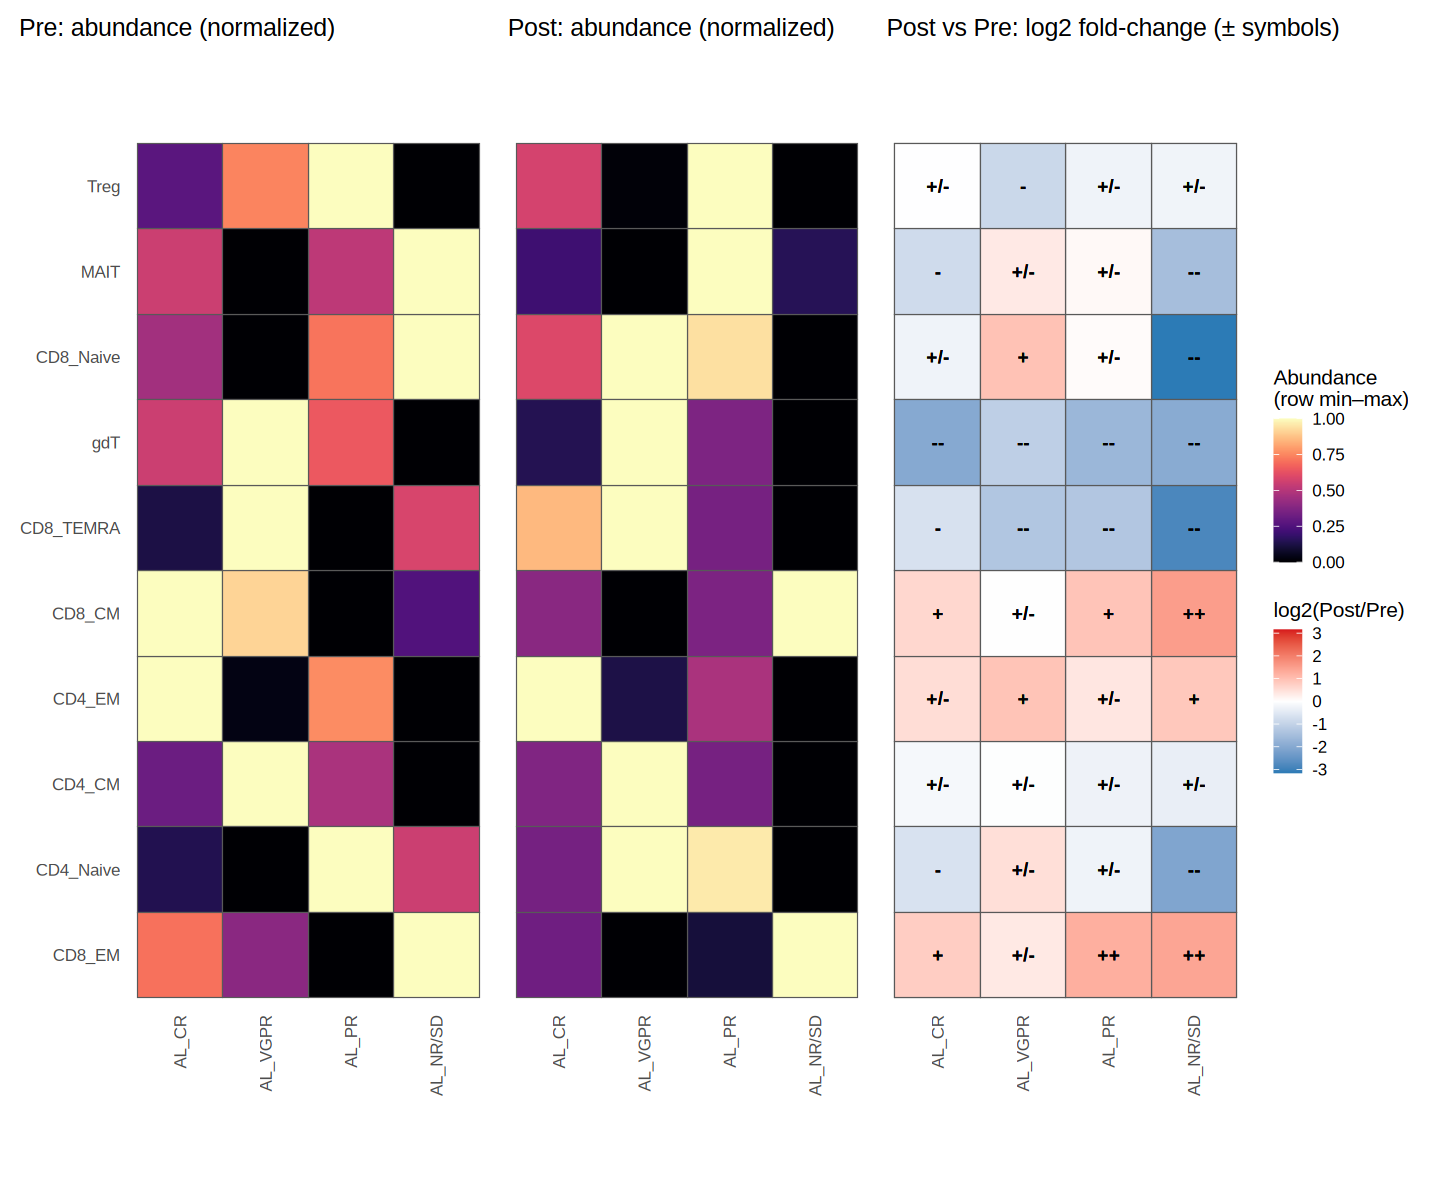

In [32]:
# --- after change_tbl is created (keep your previous wrangling) ---

suppressPackageStartupMessages({
  library(dplyr)
  library(tidyr)
  library(stringr)
  library(ggplot2)
  library(patchwork)
  library(scales)
  library(viridis)
  library(viridisLite)
})

# Join LFC and symbols onto long table
frac_rtct2 <- frac_rtct %>%
  left_join(change_tbl %>% select(response, celltype, lfc, change_sym),
            by = c("response","celltype")) %>%
  mutate(
    response  = factor(response),
    celltype  = factor(celltype),
    treatment = factor(treatment, levels = c("Pre","Post"))
  )

# ---------------------------
# 1) Normalize abundance (pattern-focused)
#   - row-wise min-max within celltype x treatment
# ---------------------------
minmax01 <- function(x) {
  rng <- range(x, na.rm = TRUE)
  if (!all(is.finite(rng)) || diff(rng) == 0) return(rep(0.5, length(x)))
  (x - rng[1]) / (rng[2] - rng[1])
}

frac_rtct2 <- frac_rtct2 %>%
  group_by(celltype, treatment) %>%
  mutate(frac_norm = minmax01(frac)) %>%
  ungroup()

# ---------------------------
# 2) LFC cap (robust scale)
# ---------------------------
lfc_cap <- suppressWarnings(quantile(abs(frac_rtct2$lfc), 0.98, na.rm = TRUE))
if (!is.finite(lfc_cap) || lfc_cap == 0) {
  lfc_cap <- max(abs(frac_rtct2$lfc), na.rm = TRUE)
  if (!is.finite(lfc_cap) || lfc_cap == 0) lfc_cap <- 1
}

# ---------------------------
# 3) Paper-friendly MAGMA palette
#    Use viridisLite::magma to avoid version issues
# ---------------------------
magma_cols <- viridisLite::magma(256)

# ---------------------------
# Theme (vertical orientation)
# ---------------------------
vertical_theme <- theme_minimal(base_size = 12) +
  theme(
    axis.text.y  = element_text(angle = 0, hjust = 1, vjust = 0.5),
    axis.text.x  = element_text(angle = 90, hjust = 1, vjust = 0.5),
    panel.grid   = element_blank(),
    plot.title.position = "plot"
  )

# ---------------------------
# 4) PRE normalized abundance heatmap (MAGMA)
# ---------------------------
p_pre <- ggplot(
  subset(frac_rtct2, treatment == "Pre"),
  aes(x = response, y = celltype, fill = frac_norm)
) +
  geom_tile(color = "grey35", linewidth = 0.25) +
  scale_fill_gradientn(
    name   = "Abundance\n(row min–max)",
    colors = magma_cols,
    limits = c(0, 1),
    oob    = scales::squish
  ) +
  coord_equal() +
  labs(title = "Pre: abundance (normalized)", x = NULL, y = NULL) +
  vertical_theme

# ---------------------------
# 5) POST normalized abundance heatmap (MAGMA)
# ---------------------------
p_post <- ggplot(
  subset(frac_rtct2, treatment == "Post"),
  aes(x = response, y = celltype, fill = frac_norm)
) +
  geom_tile(color = "grey35", linewidth = 0.25) +
  scale_fill_gradientn(
    name   = "Abundance\n(row min–max)",
    colors = magma_cols,
    limits = c(0, 1),
    oob    = scales::squish
  ) +
  coord_equal() +
  labs(title = "Post: abundance (normalized)", x = NULL, y = NULL) +
  vertical_theme +
  theme(axis.text.y = element_blank(),
        axis.ticks.y = element_blank())

# ---------------------------
# 6) POST vs PRE (log2FC) with ± symbols (keep diverging for interpretability)
# ---------------------------
p_lfc <- ggplot(
  frac_rtct2,
  aes(x = response, y = celltype, fill = lfc)
) +
  geom_tile(color = "grey35", linewidth = 0.25) +
  scale_fill_gradient2(
    name = "log2(Post/Pre)",
    low = "#2C7BB6", mid = "white", high = "#D7191C",
    midpoint = 0,
    limits = c(-lfc_cap, lfc_cap),
    oob = scales::squish
  ) +
  geom_text(
    data = subset(frac_rtct2, !is.na(change_sym)),
    aes(x = response, y = celltype, label = change_sym),
    inherit.aes = FALSE,
    color = "black", fontface = "bold", size = 4
  ) +
  coord_equal() +
  labs(title = "Post vs Pre: log2 fold-change (± symbols)", x = NULL, y = NULL) +
  vertical_theme +
  theme(axis.text.y = element_blank(),
        axis.ticks.y = element_blank())

# ---------------------------
# 7) Combine horizontally
# ---------------------------
p_three <- (p_pre | p_post | p_lfc) +
  plot_layout(guides = "collect", widths = c(1, 1, 1)) &
  theme(legend.position = "right")

options(repr.plot.height = 10, repr.plot.width = 12)
print(p_three)


## 9. Sample metadata and clinical groups


In [33]:
ggsave("Fig6b-2.pdf", plot = p_three, width = 10, height =12)


Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '(row min–max)' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '(row min–max)' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '(row min–max)' in 'mbcsToSbcs': dot substituted for <93>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '(row min–max)' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '(row min–max)' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '(row min–max)' in 'mbcsToSbcs': dot substituted for <93>”
Warning message 

Warning message:
“There was 1 warning in `summarise()`.
ℹ In argument: `cliffs_delta = tryCatch(...)`.
ℹ In group 6: `feature = Exhaustion` `group2 = Poor`.
Caused by warning in `cliff.delta.default()`:
! The samples are fully disjoint, using approximate Confidence Interval estimation”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'CliffΔ (Post vs Pre) = 0.13' in 'mbcsToSbcs': dot substituted for <ce>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'CliffΔ (Post vs Pre) = 0.13' in 'mbcsToSbcs': dot substituted for <94>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'CliffΔ (Post vs Pre) = 0.60' in 'mbcsToSbcs': dot substituted for <ce>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'CliffΔ (Post vs Pre) = 0.60' in 'mbcsToSbcs': dot substituted

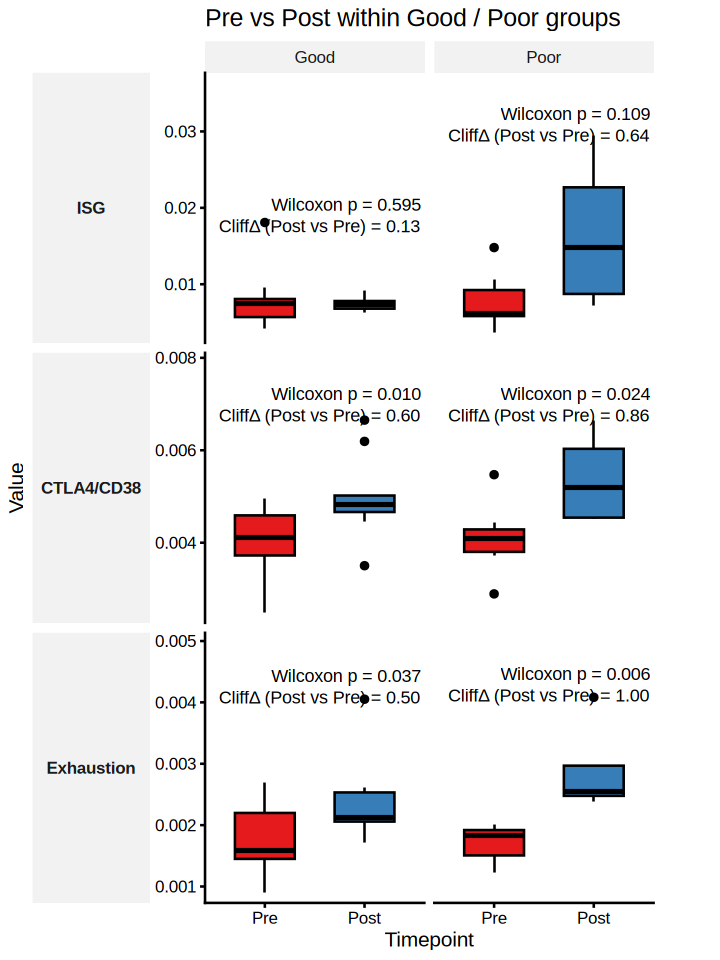

In [34]:
suppressPackageStartupMessages({
  library(dplyr)
  library(tidyr)
  library(ggpubr)
  library(RColorBrewer)
  library(broom)
  library(scales)
  library(effsize)   # for Cliff's delta
})


options(repr.plot.height = 8, repr.plot.width = 6)
selected_features <- c("ISG","CTLA4/CD38",'Exhaustion','Cytoxotic')
# --- user selection of features (unchanged) ---
usage_feats <- rownames(avg_mat)
feats_to_plot <- intersect(selected_features, usage_feats)

# Ensure desired ordering of the original response labels (if present)
boxplot$response <- factor(
  boxplot$response,
  levels = c("CR_pre","CR_post",
             "VGPR_pre","VGPR_post",
             "PR_pre","PR_post",
             "NR/SD_pre","NR/SD_post")
)

# ---------------- Long format + derive groups ----------------
df_long <- boxplot %>%
  pivot_longer(all_of(usage_feats), names_to = "feature", values_to = "value") %>%
  filter(feature %in% feats_to_plot) %>%
  mutate(
    feature        = factor(feature, levels = feats_to_plot),
    timepoint      = ifelse(grepl("pre$", response), "Pre", "Post"),
    response_group = sub("_(pre|post)$", "", response)
  ) %>%
  mutate(
    response_group = factor(response_group, levels = c("CR","VGPR","PR","NR/SD")),
    timepoint      = factor(timepoint, levels = c("Pre","Post")),
    group2         = case_when(
      response_group %in% c("CR","VGPR")   ~ "Good",
      response_group %in% c("PR","NR/SD") ~ "Poor",
      TRUE ~ NA_character_
    )
  ) %>%
  filter(!is.na(group2)) %>%
  mutate(group2 = factor(group2, levels = c("Good","Poor")))

# ---------------- y-position per (feature, group2) ----------------
row_max <- df_long %>%
  group_by(feature, group2) %>%
  summarise(ymax = max(value, na.rm = TRUE), .groups = "drop") %>%
  mutate(ypos = ifelse(is.finite(ymax), ymax * 1.05, 1))

# ---------------- Wilcoxon (Pre vs Post) per (feature, group2) ----------------
wilcox_df <- df_long %>%
  group_by(feature, group2) %>%
  summarise(
    p = tryCatch({
      has_pre  <- any(timepoint == "Pre"  & !is.na(value))
      has_post <- any(timepoint == "Post" & !is.na(value))
      if (has_pre && has_post) {
        broom::glance(wilcox.test(value ~ timepoint))$p.value
      } else {
        NA_real_
      }
    }, error = function(e) NA_real_),
    .groups = "drop"
  )

# ---------------- Cliff's delta (Post vs Pre) per (feature, group2) ----------------
cliff_df <- df_long %>%
  group_by(feature, group2) %>%
  summarise(
    cliffs_delta = tryCatch({
      pre  <- value[timepoint == "Pre"]
      post <- value[timepoint == "Post"]
      if (sum(!is.na(pre)) > 0 && sum(!is.na(post)) > 0) {
        # Positive => Post > Pre
        unname(effsize::cliff.delta(post, pre, na.rm = TRUE)$estimate)
      } else NA_real_
    }, error = function(e) NA_real_),
    .groups = "drop"
  )

# ---------------- Assemble right-side annotation: only p and CliffΔ ----------------
annot_df <- wilcox_df %>%
  left_join(row_max, by = c("feature","group2")) %>%
  left_join(cliff_df, by = c("feature","group2")) %>%
  mutate(
    label = paste0(
      "Wilcoxon p = ", ifelse(is.na(p), "NA", scales::pvalue(p)),
      "\nCliff\u0394 (Post vs Pre) = ",
      ifelse(is.na(cliffs_delta), "NA", scales::number(cliffs_delta, accuracy = 0.01))
    )
  )

# ---------------- Plot: x = timepoint, facet by group2 ----------------
p_good_vs_poor <- ggboxplot(
  df_long, x = "timepoint", y = "value", fill = "timepoint", width = 0.6
) +
  scale_fill_brewer(palette = "Set1", drop = FALSE) +
  facet_grid(feature ~ group2, scales = "free_y", switch = "y") +
  labs(x = "Timepoint", y = "Value",
       title = "Pre vs Post within Good / Poor groups") +
  theme_classic(base_size = 12) +
  theme(
    axis.text.x = element_text(angle = 0, hjust = 0.5),
    legend.position = "none",
    strip.placement = "outside",
    strip.background = element_rect(fill = "grey95", colour = NA),
    strip.text.y.left = element_text(angle = 0, face = "bold"),
    plot.margin = margin(5.5, 40, 5.5, 5.5), # extra right space for labels
    panel.spacing = unit(6, "pt")
  ) +
  scale_y_continuous(expand = expansion(mult = c(0.05, 0.25))) +
  coord_cartesian(clip = "off") +
  geom_text(
    data = annot_df,
    aes(x = Inf, y = ypos, label = label),
    inherit.aes = FALSE,
    hjust = 1.02, vjust = 0.5, lineheight = 1.05, size = 3.6
  )

p_good_vs_poor


In [35]:
ggsave("Fig6g.pdf", plot = p_good_vs_poor, width = 5, height =6)


Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'CliffΔ (Post vs Pre) = 0.13' in 'mbcsToSbcs': dot substituted for <ce>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'CliffΔ (Post vs Pre) = 0.13' in 'mbcsToSbcs': dot substituted for <94>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'CliffΔ (Post vs Pre) = 0.13' in 'mbcsToSbcs': dot substituted for <ce>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'CliffΔ (Post vs Pre) = 0.13' in 'mbcsToSbcs': dot substituted for <94>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'CliffΔ (Post vs Pre) = 0.60' in 'mbcsToSbcs': dot substituted for <ce>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversio

In [36]:
Idents(sce1_tcell)<-'Annotation'

# Create a custom blue to yellow color palette
blue_red_palette <- colorRampPalette(c("steelblue", "white", "firebrick"))

# Define a color vector with 26 colors
cols_vec <- colorRampPalette(c("steelblue", "white", "firebrick"))(26)

# all marker
allgene<- c(
"CD38",'PTGS2','PTGER2','PTGER4','PTGES2','PTGES3','KLRK1','LILRB1','HCST'
) 


In [37]:
library(RColorBrewer)

# Define a color vector with 26 colors
cols_vec <- colorRampPalette(c("steelblue", "white", "firebrick"))(26)

# Use DotPlot with the color palette

# Re-run DotPlot with deduplicated genes
initial_plot <- DotPlot(sce1_tcell, features = unique(allgene),  scale = TRUE, cols = cols_vec)

# Extract and plot
plot_data <- initial_plot$data


## 10. Sample metadata and clinical groups


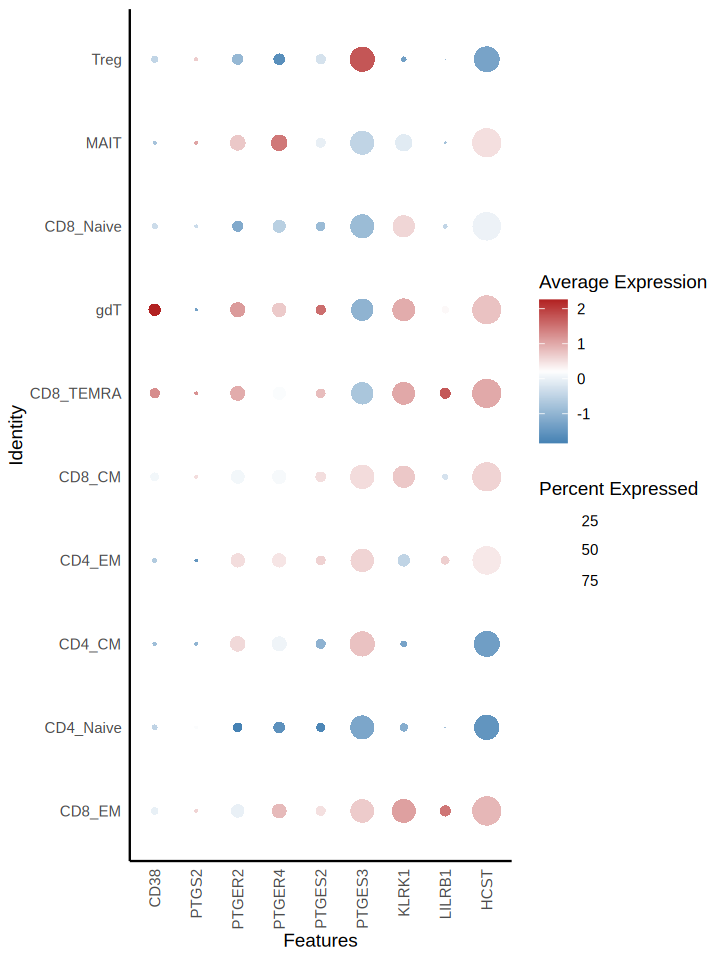

In [38]:
# 1) Define the exact order you want (top -> bottom)
row_order <- unique(plot_data$id)[c(5,3,1,2,4,7,8,6,9,10)]
# 2) Apply it (this controls ggplot row order)
plot_data$id <- factor(plot_data$id, levels = row_order)

# 3) Plot
p <- ggplot(plot_data, aes(x = features.plot, y = id)) +
  geom_point(aes(size = pct.exp, fill = avg.exp.scaled),
             shape = 21, color = "black", stroke = 0) +
  scale_size(range = c(0, 8), name = "Percent Expressed") +
  scale_fill_gradientn(colors = blue_red_palette(100), name = "Average Expression") +
  theme_minimal() +
  theme(
    axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    panel.background = element_blank(),
    axis.line = element_line(color = "black")
  ) +
  labs(x = "Features", y = "Identity")

p


In [39]:
ggsave("Fig6c-2.pdf", plot = p, width =5, height =6)

In [40]:
source("enrichment_utils_C5.R")

# Change this for each dataset
obj <- sce1_tcell

# Assay/layer
assay_use <- DefaultAssay(obj)
layer_use <- "data"

# Metadata columns in obj@meta.data
celltype_col <- "final_label"   # e.g. "Annotation" or "predicted_CellType"
treat_col    <- "treatment"     # expected values: "Pre", "Post"
resp_col     <- "response"      # e.g. "AL_CR", "AL_VGPR", "AL_PR", "AL_NR/SD"

# Response grouping
good_set <- c("AL_CR", "AL_VGPR")
poor_set <- c("AL_PR", "AL_NR/SD")

# Optional cell type order for heatmap x-axis
celltype_order <- unique(obj@meta.data[[celltype_col]])


# Change only these regex terms for each biological question
focus_regex <-"(INTERFERON)"
C2_regex <- paste(c("CTLA4","T_CELL_EXHAUST"  ), collapse = "|")
C7_regex <- paste(c("CTLA4","T_CELL_EXHAUST"  ), collapse = "|")
C5_regex <- paste(c("CTLA4","T_CELL_EXHAUST"  ), collapse = "|")

res <- run_combined_progeny_ssgsea(
  obj = obj,
  assay_use = assay_use,
  layer_use = layer_use,
  celltype_col = celltype_col,
  treat_col = treat_col,
  resp_col = resp_col,
  good_set = good_set,
  poor_set = poor_set,
  species = "Homo sapiens",

  # Hallmark
  focus_only = TRUE,
  focus_regex = focus_regex,

  # C2/C7
  include_C2_C7 = TRUE,
  C2_regex = C2_regex,
  C7_regex = C7_regex,

  # C5 / GO
  include_C5 = TRUE,
  C5_subcats = c("GO:BP", "GO:CC", "GO:MF", "HPO"),
  C5_regex = C5_regex,

  exclude_ssgsea_regex = "GSE|GSM",

  min_cells_per_group = 3,
  celltype_order = celltype_order,
  heatmap_width = 4.8,
  heatmap_height = 2.8,

  # output
  out_dir = "./results/tcell_INTERFERON_PROGENy_ssGSEA"
)


# Per-cell PROGENy and ssGSEA scores
head(res$all_cell_scores)

# Post vs Pre within Good/Poor response groups
head(res$post_vs_pre_delta)

# Poor vs Good within Pre/Post treatment groups
head(res$poor_vs_good_delta)

# Output file paths
res$output_files




Warning message:
“The `slot` argument of `GetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.”
Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 36.8 GiB”
Warning message:
“Layer counts isn't present in the assay object; returning NULL”
Warning message:
“Calling gsva(expr=., gset.idx.list=., method=., ...) is deprecated; use a method-specific parameter object (see '?gsva').”
Warning message in .filterFeatures(expr, method):
“10 genes with constant expression values throughout the samples.”


Estimating ssGSEA scores for 5 gene sets.
[1] "Calculating ranks..."
[1] "Calculating absolute values from ranks..."
  |======================================================================| 100%

[1] "Normalizing..."


Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PROGENy • JAK-STAT' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PROGENy • JAK-STAT' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PROGENy • JAK-STAT' in 'mbcsToSbcs': dot substituted for <a2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PROGENy • NFkB' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PROGENy • NFkB' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PROGENy • NFkB' in 'mbcsToSbcs': dot substituted for <a2>

Method,cell_id,Annotation,treatment,response,resp_group,pathway,score_raw,score_z
<chr>,<chr>,<fct>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>
PROGENy,ALl14_AAACCCAGTTAAACCC-1,CD4_CM,Pre,AL_CR,Good,Hypoxia,-0.20940517,-0.192723599
PROGENy,ALl14_AAACCCAGTTAAACCC-1,CD4_CM,Pre,AL_CR,Good,JAK-STAT,-0.61625261,-0.579128447
PROGENy,ALl14_AAACCCAGTTAAACCC-1,CD4_CM,Pre,AL_CR,Good,NFkB,-0.02835135,0.006865047
PROGENy,ALl14_AAACCCAGTTAAACCC-1,CD4_CM,Pre,AL_CR,Good,TGFb,-0.76445354,-0.727242217
PROGENy,ALl14_AAACCCAGTTAAACCC-1,CD4_CM,Pre,AL_CR,Good,TNFa,0.17368402,0.206302840
PROGENy,ALl14_AAACCCATCTGTAACG-1,CD4_CM,Pre,AL_CR,Good,Hypoxia,0.90549680,0.921370124


Method,contrast,Annotation,response_group,pathway,n_pre,n_post,mean_pre,mean_post,deltaNES,p_value,padj,star
<chr>,<chr>,<fct>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
PROGENy,Post_vs_Pre_within_response,CD4_CM,Good,Hypoxia,9045,2879,0.12151074,-0.02636419,-0.14787493,6.741140e-13,6.741140e-13,***
PROGENy,Post_vs_Pre_within_response,CD4_CM,Good,JAK-STAT,9045,2879,-0.31902967,-0.26628449,0.05274518,1.841616e-04,1.841616e-04,***
PROGENy,Post_vs_Pre_within_response,CD4_CM,Good,NFkB,9045,2879,-0.22713366,-0.39565881,-0.16852515,2.125653e-19,2.125653e-19,***
PROGENy,Post_vs_Pre_within_response,CD4_CM,Good,TGFb,9045,2879,-0.17162506,-0.20067570,-0.02905064,8.073285e-02,8.073285e-02,
PROGENy,Post_vs_Pre_within_response,CD4_CM,Good,TNFa,9045,2879,-0.09101605,-0.24994902,-0.15893297,1.997472e-15,1.997472e-15,***
PROGENy,Post_vs_Pre_within_response,CD4_CM,Poor,Hypoxia,3778,2010,0.03656054,0.23683026,0.20026972,9.232472e-16,1.846494e-15,***


Method,contrast,Annotation,treatment_group,pathway,n_good,n_poor,mean_good,mean_poor,deltaNES,p_value,padj,star
<chr>,<chr>,<fct>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
PROGENy,Poor_vs_Good_within_treatment,CD4_CM,Post,Hypoxia,2879,2010,-0.02636419,0.23683026,0.2631944,5.258175e-24,1.051635e-23,***
PROGENy,Poor_vs_Good_within_treatment,CD4_CM,Post,JAK-STAT,2879,2010,-0.26628449,0.44691451,0.7131990,2.269857e-102,4.539713e-102,***
PROGENy,Poor_vs_Good_within_treatment,CD4_CM,Post,NFkB,2879,2010,-0.39565881,0.22816559,0.6238244,3.848399e-128,7.696798e-128,***
PROGENy,Poor_vs_Good_within_treatment,CD4_CM,Post,TGFb,2879,2010,-0.20067570,-0.04207366,0.1586020,1.173647e-10,2.347295e-10,***
PROGENy,Poor_vs_Good_within_treatment,CD4_CM,Post,TNFa,2879,2010,-0.24994902,0.37866998,0.6286190,4.399372e-118,8.798743e-118,***
PROGENy,Poor_vs_Good_within_treatment,CD4_CM,Pre,Hypoxia,9045,3778,0.12151074,0.03656054,-0.0849502,1.096566e-05,1.096566e-05,***


$gene_sets_txt
[1] "./results/tcell_INTERFERON_PROGENy_ssGSEA/ssgsea_gene_sets_used.txt"

$all_cell_scores_csv
[1] "./results/tcell_INTERFERON_PROGENy_ssGSEA/all_cell_scores_PROGENy_ssGSEA.csv.gz"

$post_vs_pre_csv
[1] "./results/tcell_INTERFERON_PROGENy_ssGSEA/deltaNES_Post_vs_Pre_within_GoodPoor.csv.gz"

$poor_vs_good_csv
[1] "./results/tcell_INTERFERON_PROGENy_ssGSEA/deltaNES_Poor_vs_Good_within_PrePost.csv.gz"

$all_delta_scores_csv
[1] "./results/tcell_INTERFERON_PROGENy_ssGSEA/all_delta_scores_two_contrasts_PROGENy_ssGSEA.csv.gz"

$heatmap_post_vs_pre_pdf
[1] "./results/tcell_INTERFERON_PROGENy_ssGSEA/heatmap1_Post_vs_Pre_grouped_by_GoodPoor_extra_compact.pdf"

$heatmap_post_vs_pre_png
[1] "./results/tcell_INTERFERON_PROGENy_ssGSEA/heatmap1_Post_vs_Pre_grouped_by_GoodPoor_extra_compact.png"

$heatmap_poor_vs_good_pdf
[1] "./results/tcell_INTERFERON_PROGENy_ssGSEA/heatmap2_Poor_vs_Good_grouped_by_PrePost_extra_compact.pdf"

$heatmap_poor_vs_good_png
[1] "./results/tcell_INTERFERON_PROGENy_ssGSEA/heatmap2_Poor_vs_Good_grouped_by_PrePost_extra_compact.png"

## 11. Sample metadata and clinical groups


In [41]:
source("enrichment_utils_C5.R")

# Change this for each dataset
obj <- sce1_tcell

# Assay/layer
assay_use <- DefaultAssay(obj)
layer_use <- "data"

# Metadata columns in obj@meta.data
celltype_col <- "final_label"   # e.g. "Annotation" or "predicted_CellType"
treat_col    <- "treatment"     # expected values: "Pre", "Post"
resp_col     <- "response"      # e.g. "AL_CR", "AL_VGPR", "AL_PR", "AL_NR/SD"

# Response grouping
good_set <- c("AL_CR", "AL_VGPR")
poor_set <- c("AL_PR", "AL_NR/SD")

# Optional cell type order for heatmap x-axis
celltype_order <- unique(obj@meta.data[[celltype_col]])


# Change only these regex terms for each biological question
focus_regex <-"(INTERFERON)"
C2_regex <- paste(c( "CTLA4","T_CELL_EXHAUST"  ), collapse = "|")
C7_regex <- paste(c("CTLA4","T_CELL_EXHAUST"  ), collapse = "|")
C5_regex <- paste(c("CTLA4","T_CELL_EXHAUST"  ), collapse = "|")

res <- run_combined_progeny_ssgsea(
  obj = obj,
  assay_use = assay_use,
  layer_use = layer_use,
  celltype_col = celltype_col,
  treat_col = treat_col,
  resp_col = resp_col,
  good_set = good_set,
  poor_set = poor_set,
  species = "Homo sapiens",

  # Hallmark
  focus_only = TRUE,
  focus_regex = focus_regex,

  # C2/C7
  include_C2_C7 = TRUE,
  C2_regex = C2_regex,
  C7_regex = C7_regex,

  # C5 / GO
  include_C5 = TRUE,
  C5_subcats = c("GO:BP", "GO:CC", "GO:MF", "HPO"),
  C5_regex = C5_regex,

  exclude_ssgsea_regex = "GSE|GSM",

  min_cells_per_group = 3,
  celltype_order = celltype_order,
  heatmap_width = 4.8,
  heatmap_height = 2.8,

  # output
  out_dir = "./results/tcell_INTERFERON_PROGENy_ssGSEA"
)


# Per-cell PROGENy and ssGSEA scores
head(res$all_cell_scores)

# Post vs Pre within Good/Poor response groups
head(res$post_vs_pre_delta)

# Poor vs Good within Pre/Post treatment groups
head(res$poor_vs_good_delta)

# Output file paths
res$output_files




Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 36.8 GiB”
Warning message:
“Layer counts isn't present in the assay object; returning NULL”
Warning message:
“Calling gsva(expr=., gset.idx.list=., method=., ...) is deprecated; use a method-specific parameter object (see '?gsva').”
Warning message in .filterFeatures(expr, method):
“10 genes with constant expression values throughout the samples.”


Estimating ssGSEA scores for 5 gene sets.
[1] "Calculating ranks..."
[1] "Calculating absolute values from ranks..."
  |======================================================================| 100%

[1] "Normalizing..."


Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PROGENy • JAK-STAT' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PROGENy • JAK-STAT' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PROGENy • JAK-STAT' in 'mbcsToSbcs': dot substituted for <a2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PROGENy • NFkB' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PROGENy • NFkB' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PROGENy • NFkB' in 'mbcsToSbcs': dot substituted for <a2>

Method,cell_id,Annotation,treatment,response,resp_group,pathway,score_raw,score_z
<chr>,<chr>,<fct>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>
PROGENy,ALl14_AAACCCAGTTAAACCC-1,CD4_CM,Pre,AL_CR,Good,Hypoxia,-0.20940517,-0.192723599
PROGENy,ALl14_AAACCCAGTTAAACCC-1,CD4_CM,Pre,AL_CR,Good,JAK-STAT,-0.61625261,-0.579128447
PROGENy,ALl14_AAACCCAGTTAAACCC-1,CD4_CM,Pre,AL_CR,Good,NFkB,-0.02835135,0.006865047
PROGENy,ALl14_AAACCCAGTTAAACCC-1,CD4_CM,Pre,AL_CR,Good,TGFb,-0.76445354,-0.727242217
PROGENy,ALl14_AAACCCAGTTAAACCC-1,CD4_CM,Pre,AL_CR,Good,TNFa,0.17368402,0.206302840
PROGENy,ALl14_AAACCCATCTGTAACG-1,CD4_CM,Pre,AL_CR,Good,Hypoxia,0.90549680,0.921370124


Method,contrast,Annotation,response_group,pathway,n_pre,n_post,mean_pre,mean_post,deltaNES,p_value,padj,star
<chr>,<chr>,<fct>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
PROGENy,Post_vs_Pre_within_response,CD4_CM,Good,Hypoxia,9045,2879,0.12151074,-0.02636419,-0.14787493,6.741140e-13,6.741140e-13,***
PROGENy,Post_vs_Pre_within_response,CD4_CM,Good,JAK-STAT,9045,2879,-0.31902967,-0.26628449,0.05274518,1.841616e-04,1.841616e-04,***
PROGENy,Post_vs_Pre_within_response,CD4_CM,Good,NFkB,9045,2879,-0.22713366,-0.39565881,-0.16852515,2.125653e-19,2.125653e-19,***
PROGENy,Post_vs_Pre_within_response,CD4_CM,Good,TGFb,9045,2879,-0.17162506,-0.20067570,-0.02905064,8.073285e-02,8.073285e-02,
PROGENy,Post_vs_Pre_within_response,CD4_CM,Good,TNFa,9045,2879,-0.09101605,-0.24994902,-0.15893297,1.997472e-15,1.997472e-15,***
PROGENy,Post_vs_Pre_within_response,CD4_CM,Poor,Hypoxia,3778,2010,0.03656054,0.23683026,0.20026972,9.232472e-16,1.846494e-15,***


Method,contrast,Annotation,treatment_group,pathway,n_good,n_poor,mean_good,mean_poor,deltaNES,p_value,padj,star
<chr>,<chr>,<fct>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
PROGENy,Poor_vs_Good_within_treatment,CD4_CM,Post,Hypoxia,2879,2010,-0.02636419,0.23683026,0.2631944,5.258175e-24,1.051635e-23,***
PROGENy,Poor_vs_Good_within_treatment,CD4_CM,Post,JAK-STAT,2879,2010,-0.26628449,0.44691451,0.7131990,2.269857e-102,4.539713e-102,***
PROGENy,Poor_vs_Good_within_treatment,CD4_CM,Post,NFkB,2879,2010,-0.39565881,0.22816559,0.6238244,3.848399e-128,7.696798e-128,***
PROGENy,Poor_vs_Good_within_treatment,CD4_CM,Post,TGFb,2879,2010,-0.20067570,-0.04207366,0.1586020,1.173647e-10,2.347295e-10,***
PROGENy,Poor_vs_Good_within_treatment,CD4_CM,Post,TNFa,2879,2010,-0.24994902,0.37866998,0.6286190,4.399372e-118,8.798743e-118,***
PROGENy,Poor_vs_Good_within_treatment,CD4_CM,Pre,Hypoxia,9045,3778,0.12151074,0.03656054,-0.0849502,1.096566e-05,1.096566e-05,***


$gene_sets_txt
[1] "./results/tcell_INTERFERON_PROGENy_ssGSEA/ssgsea_gene_sets_used.txt"

$all_cell_scores_csv
[1] "./results/tcell_INTERFERON_PROGENy_ssGSEA/all_cell_scores_PROGENy_ssGSEA.csv.gz"

$post_vs_pre_csv
[1] "./results/tcell_INTERFERON_PROGENy_ssGSEA/deltaNES_Post_vs_Pre_within_GoodPoor.csv.gz"

$poor_vs_good_csv
[1] "./results/tcell_INTERFERON_PROGENy_ssGSEA/deltaNES_Poor_vs_Good_within_PrePost.csv.gz"

$all_delta_scores_csv
[1] "./results/tcell_INTERFERON_PROGENy_ssGSEA/all_delta_scores_two_contrasts_PROGENy_ssGSEA.csv.gz"

$heatmap_post_vs_pre_pdf
[1] "./results/tcell_INTERFERON_PROGENy_ssGSEA/heatmap1_Post_vs_Pre_grouped_by_GoodPoor_extra_compact.pdf"

$heatmap_post_vs_pre_png
[1] "./results/tcell_INTERFERON_PROGENy_ssGSEA/heatmap1_Post_vs_Pre_grouped_by_GoodPoor_extra_compact.png"

$heatmap_poor_vs_good_pdf
[1] "./results/tcell_INTERFERON_PROGENy_ssGSEA/heatmap2_Poor_vs_Good_grouped_by_PrePost_extra_compact.pdf"

$heatmap_poor_vs_good_png
[1] "./results/tcell_INTERFERON_PROGENy_ssGSEA/heatmap2_Poor_vs_Good_grouped_by_PrePost_extra_compact.png"

In [50]:
# ------------------------------------------------------------
# Read IFN/interferon gene signatures from CSV
# Each column = one signature
# Column name = signature name
# Non-empty values in that column = genes
# ------------------------------------------------------------

ifn_gene_df <- read.csv(
  "intergerongenes.csv",
  header = TRUE,
  stringsAsFactors = FALSE,
  check.names = FALSE
)

custom_ifn_gene_sets <- lapply(ifn_gene_df, function(genes) {
  genes <- trimws(as.character(genes))
  genes <- genes[!is.na(genes) & genes != ""]
  unique(genes)
})

# Optional checks
names(custom_ifn_gene_sets)
str(custom_ifn_gene_sets)
# Optional: keep only genes present in this Seurat object
genes_present <- rownames(obj)

custom_ifn_gene_sets <- lapply(custom_ifn_gene_sets, function(x) {
  unique(intersect(x, genes_present))
})

# Keep one-gene sets because TNK_IFNAB_SPECIFIC and TNK_IFNG_SPECIFIC are biologically intentional.
custom_ifn_gene_sets <- custom_ifn_gene_sets[lengths(custom_ifn_gene_sets) >= 1]

message("Custom IFN gene sets retained:")
print(sapply(custom_ifn_gene_sets, length))

[1] "REACTOME_INTERFERON_ALPHA_BETA_SIGNALING"
[2] "REACTOME_INTERFERON_GAMMA_SIGNALING"     
[3] "BIOCARTA_IFNA_PATHWAY"                   
[4] "BIOCARTA_IFNG_PATHWAY"

List of 4
 $ REACTOME_INTERFERON_ALPHA_BETA_SIGNALING: chr [1:78] "ABCE1" "ADAR" "BST2" "EGR1" ...
 $ REACTOME_INTERFERON_GAMMA_SIGNALING     : chr [1:98] "B2M" "CAMK2A" "CAMK2B" "CAMK2D" ...
 $ BIOCARTA_IFNA_PATHWAY                   : chr [1:9] "IFNA1" "IFNAR1" "IFNAR2" "IFNB1" ...
 $ BIOCARTA_IFNG_PATHWAY                   : chr [1:6] "IFNG" "IFNGR1" "IFNGR2" "JAK1" ...


Custom IFN gene sets retained:



REACTOME_INTERFERON_ALPHA_BETA_SIGNALING 
                                      77 
     REACTOME_INTERFERON_GAMMA_SIGNALING 
                                      94 
                   BIOCARTA_IFNA_PATHWAY 
                                       9 
                   BIOCARTA_IFNG_PATHWAY 
                                       6 


In [51]:
source("enrichment_utils_C5_custom_IFN.R")

res <- run_combined_progeny_ssgsea(
  obj = obj,
  assay_use = assay_use,
  layer_use = layer_use,
  celltype_col = celltype_col,
  treat_col = treat_col,
  resp_col = resp_col,
  good_set = good_set,
  poor_set = poor_set,
  species = "Homo sapiens",

  # Hallmark
  focus_only = TRUE,
  focus_regex = focus_regex,

  # C2/C7
  include_C2_C7 = TRUE,
  C2_regex = C2_regex,
  C7_regex = C7_regex,

  # C5 / GO
  include_C5 = TRUE,
  C5_subcats = c("GO:BP", "GO:CC", "GO:MF", "HPO"),
  C5_regex = C5_regex,

  # Custom IFN gene sets
  custom_gene_sets = custom_ifn_gene_sets,
  custom_gene_set_prefix = "CUSTOM_IFN",
  min_genes_per_custom_set = 1,

  exclude_ssgsea_regex = "GSE|GSM",

  min_cells_per_group = 3,
  celltype_order = celltype_order,
  heatmap_width = 4.8,
  heatmap_height = 2.8,

  out_dir = "./results/tcell_INTERFERON_PROGENy_ssGSEA"
)

Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 36.8 GiB”
Warning message:
“Layer counts isn't present in the assay object; returning NULL”
Added custom gene sets: CUSTOM_IFN_REACTOME_INTERFERON_ALPHA_BETA_SIGNALING, CUSTOM_IFN_REACTOME_INTERFERON_GAMMA_SIGNALING, CUSTOM_IFN_BIOCARTA_IFNA_PATHWAY, CUSTOM_IFN_BIOCARTA_IFNG_PATHWAY

Warning message:
“Calling gsva(expr=., gset.idx.list=., method=., ...) is deprecated; use a method-specific parameter object (see '?gsva').”
Warning message in .filterFeatures(expr, method):
“23 genes with constant expression values throughout the samples.”


Estimating ssGSEA scores for 9 gene sets.
[1] "Calculating ranks..."
[1] "Calculating absolute values from ranks..."
  |======================================================================| 100%

[1] "Normalizing..."


Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'ssGSEA • HALLMARK_INTERFERON_GAMMA_RESPONSE' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'ssGSEA • HALLMARK_INTERFERON_GAMMA_RESPONSE' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'ssGSEA • HALLMARK_INTERFERON_GAMMA_RESPONSE' in 'mbcsToSbcs': dot substituted for <a2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'ssGSEA • CUSTOM_IFN_REACTOME_INTERFERON_GAMMA_SIGNALING' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'ssGSEA • CUSTOM_IFN_REACTOME_INTERFERON_GAMMA_SIGNALING' in 'mbcsToSbcs': dot substituted for <80>”
Warnin

In [44]:
source("enrichment_utils_C5_custom_PGE.R")
res_ptger <- run_receptor_stratified_ssgsea(
  obj = obj,
  assay_use = assay_use,
  layer_use = layer_use,
  deg_layer_use = layer_use,

  celltype_col = celltype_col,
  sample_col = NULL,  # replace with patient/sample column if available
  treat_col = treat_col,
  resp_col = resp_col,

  receptor_genes = c("PTGER2", "PTGER4"),
  species = "Homo sapiens",

  # default is now High PTGER2/PTGER4 vs Low PTGER2/PTGER4
  contrast_group1 = NULL,
  contrast_group2 = NULL,

  # default uses focused EP2/EP4 downstream + immune-program regex
  enrichment_focus_regex = NULL,

  min_cells_per_group = 10,
  min_cells_for_deg = 20,
  top_n_pathways = 30,
  top_n_deg = 10,

  out_dir = "./results/PTGER2_PTGER4_High_vs_Low_focused_ssGSEA_DEG_tcell"
)

head(res_ptger$ssgsea_stats)
head(res_ptger$pseudobulk_deg)
res_ptger$output_files

Focused gene sets retained: 12

Examples: HALLMARK_ALLOGRAFT_REJECTION | HALLMARK_APICAL_JUNCTION | HALLMARK_IL2_STAT5_SIGNALING | HALLMARK_INFLAMMATORY_RESPONSE | HALLMARK_INTERFERON_ALPHA_RESPONSE | HALLMARK_INTERFERON_GAMMA_RESPONSE | HALLMARK_MTORC1_SIGNALING | HALLMARK_MYC_TARGETS_V1 | HALLMARK_MYC_TARGETS_V2 | HALLMARK_OXIDATIVE_PHOSPHORYLATION | HALLMARK_PI3K_AKT_MTOR_SIGNALING | HALLMARK_TNFA_SIGNALING_VIA_NFKB

Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 1.6 GiB”
Warning message:
“Calling gsva(expr=., gset.idx.list=., method=., ...) is deprecated; use a method-specific parameter object (see '?gsva').”
Warning message in .filterFeatures(expr, method):
“22 genes with constant expression values throughout the samples.”


Estimating ssGSEA scores for 12 gene sets.
[1] "Calculating ranks..."
[1] "Calculating absolute values from ranks..."
  |======================================================================| 100%

[1] "Normalizing..."


sample_col is NULL. Pseudobulk DEG is descriptive mean difference only; p-values require biological/sample replicates.

Comparison: High PTGER2/PTGER4 - Low PTGER2/PTGER4

Done. Output directory: ./results/PTGER2_PTGER4_High_vs_Low_focused_ssGSEA_DEG_tcell



Annotation,pathway,group1,group2,n_group1,n_group2,mean_group1,mean_group2,delta_score,p_value,padj,star,pathway_clean,direction
<chr>,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
CD8_CM,HALLMARK_INFLAMMATORY_RESPONSE,Low PTGER2/PTGER4,High PTGER2/PTGER4,1752,1752,-1.0480454,0.20431807,1.2523634,8.075944e-152,9.691133e-151,***,INFLAMMATORY RESPONSE,Up in High PTGER2/PTGER4
CD4_EM,HALLMARK_INFLAMMATORY_RESPONSE,Low PTGER2/PTGER4,High PTGER2/PTGER4,2464,2463,-0.2495453,0.44354867,0.6930939,3.389214e-150,4.067057e-149,***,INFLAMMATORY RESPONSE,Up in High PTGER2/PTGER4
CD4_CM,HALLMARK_INFLAMMATORY_RESPONSE,Low PTGER2/PTGER4,High PTGER2/PTGER4,2888,2887,-0.4290162,0.36402884,0.7930450,4.048973e-149,4.858768e-148,***,INFLAMMATORY RESPONSE,Up in High PTGER2/PTGER4
CD4_CM,HALLMARK_MYC_TARGETS_V1,Low PTGER2/PTGER4,High PTGER2/PTGER4,2888,2887,1.1027859,0.34562825,-0.7571577,2.468740e-143,1.481244e-142,***,MYC TARGETS V1,Up in Low PTGER2/PTGER4
CD8_EM,HALLMARK_INFLAMMATORY_RESPONSE,Low PTGER2/PTGER4,High PTGER2/PTGER4,2381,2380,-0.6069367,0.09926982,0.7062065,1.866512e-142,2.239814e-141,***,INFLAMMATORY RESPONSE,Up in High PTGER2/PTGER4
CD4_EM,HALLMARK_MYC_TARGETS_V1,Low PTGER2/PTGER4,High PTGER2/PTGER4,2464,2463,0.2776287,-0.36709126,-0.6447200,1.205444e-141,7.232664e-141,***,MYC TARGETS V1,Up in Low PTGER2/PTGER4


Annotation,gene,group1,group2,n_cells_group1,n_cells_group2,n_pseudobulk_group1,n_pseudobulk_group2,avg_group1,avg_group2,avg_logFC,p_value,padj
<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
CD4_CM,MIR1302-2HG,Low PTGER2/PTGER4,High PTGER2/PTGER4,2888,2887,1,1,0.0000000000,0.0000000000,0.0000000000,NA,NA
CD4_CM,FAM138A,Low PTGER2/PTGER4,High PTGER2/PTGER4,2888,2887,1,1,0.0000000000,0.0000000000,0.0000000000,NA,NA
CD4_CM,OR4F5,Low PTGER2/PTGER4,High PTGER2/PTGER4,2888,2887,1,1,0.0000000000,0.0000000000,0.0000000000,NA,NA
CD4_CM,AL627309.1,Low PTGER2/PTGER4,High PTGER2/PTGER4,2888,2887,1,1,0.0020244777,0.0004352368,-0.0015892410,NA,NA
CD4_CM,AL627309.3,Low PTGER2/PTGER4,High PTGER2/PTGER4,2888,2887,1,1,0.0003190466,0.0000000000,-0.0003190466,NA,NA
CD4_CM,AL627309.2,Low PTGER2/PTGER4,High PTGER2/PTGER4,2888,2887,1,1,0.0000000000,0.0000000000,0.0000000000,NA,NA


$meta_receptor_csv
[1] "./results/PTGER2_PTGER4_High_vs_Low_focused_ssGSEA_DEG_tcell/cell_receptor_groups.csv.gz"

$receptor_stack_pdf
[1] "./results/PTGER2_PTGER4_High_vs_Low_focused_ssGSEA_DEG_tcell/receptor_group_stackplot_by_celltype.pdf"

$receptor_stack_png
[1] "./results/PTGER2_PTGER4_High_vs_Low_focused_ssGSEA_DEG_tcell/receptor_group_stackplot_by_celltype.png"

$receptor_coexp_dot_pdf
[1] "./results/PTGER2_PTGER4_High_vs_Low_focused_ssGSEA_DEG_tcell/receptor_coexpression_dotplot.pdf"

$receptor_coexp_dot_png
[1] "./results/PTGER2_PTGER4_High_vs_Low_focused_ssGSEA_DEG_tcell/receptor_coexpression_dotplot.png"

$gene_sets_txt
[1] "./results/PTGER2_PTGER4_High_vs_Low_focused_ssGSEA_DEG_tcell/focused_ssgsea_gene_sets_used.txt"

$ssgsea_cell_scores_csv
[1] "./results/PTGER2_PTGER4_High_vs_Low_focused_ssGSEA_DEG_tcell/single_cell_focused_ssGSEA_scores.csv.gz"

$ssgsea_stats_csv
[1] "./results/PTGER2_PTGER4_High_vs_Low_focused_ssGSEA_DEG_tcell/focused_ssGSEA_high_vs_low_stats.csv.gz"

$ssgsea_diff_pdf
[1] "./results/PTGER2_PTGER4_High_vs_Low_focused_ssGSEA_DEG_tcell/focused_ssGSEA_high_vs_low_barplot.pdf"

$ssgsea_diff_png
[1] "./results/PTGER2_PTGER4_High_vs_Low_focused_ssGSEA_DEG_tcell/focused_ssGSEA_high_vs_low_barplot.png"

$pseudobulk_deg_csv
[1] "./results/PTGER2_PTGER4_High_vs_Low_focused_ssGSEA_DEG_tcell/pseudobulk_DEG_high_vs_low_stats.csv.gz"

$pseudobulk_deg_top_pdf
[1] "./results/PTGER2_PTGER4_High_vs_Low_focused_ssGSEA_DEG_tcell/pseudobulk_DEG_high_vs_low_top_up_down_barplot.pdf"

$pseudobulk_deg_top_png
[1] "./results/PTGER2_PTGER4_High_vs_Low_focused_ssGSEA_DEG_tcell/pseudobulk_DEG_high_vs_low_top_up_down_barplot.png"

In [45]:
suppressPackageStartupMessages({
  library(Seurat)
  library(dplyr)
  library(tidyr)
  library(tibble)
  library(ggplot2)
  library(ggpubr)
  library(RColorBrewer)
  library(broom)
  library(scales)
  library(effsize)
  library(stringr)
})

# =========================================================
# 0) SETTINGS
# =========================================================
sample_col <- "orig.ident"
celltype_col <- "Annotation"
assay_use <- "RNA"

marker_pos_cutoff <- 0
min_cells_per_sample_group <- 5

marker_map <- c(
  LAG3   = "LAG3",
  TIGIT  = "TIGIT",
  HAVCR2 = "HAVCR2",
  CTLA4  = "CTLA4",
  PDCD1  = "PDCD1"
)

response_levels <- c("AL_CR", "AL_VGPR", "AL_PR", "AL_NR/SD")

outdir_pdf <- "isolated_boxplots_by_celltype_good_poor"
dir.create(outdir_pdf, showWarnings = FALSE, recursive = TRUE)

# =========================================================
# 1) REQUIRED META CHECK
# =========================================================
required_meta <- c("label", sample_col, celltype_col)

missing_meta <- setdiff(required_meta, colnames(sce1_tcell@meta.data))

if (length(missing_meta) > 0) {
  stop("Missing metadata columns: ", paste(missing_meta, collapse = ", "))
}

# =========================================================
# 2) CLEAN LABELS / DERIVE RESPONSE, TREATMENT, RESPONSE GROUP
# =========================================================
sce1_tcell$label <- as.character(sce1_tcell$label)
sce1_tcell$label <- gsub("[[:space:]'‘’\"“”]", "", sce1_tcell$label)

meta_df <- sce1_tcell@meta.data %>%
  as.data.frame() %>%
  rownames_to_column("cell_id") %>%
  mutate(
    label_clean = gsub("[[:space:]'‘’\"“”]", "", as.character(label)),

    response = sub(
      pattern = "_(pre|post)$",
      replacement = "",
      x = label_clean,
      ignore.case = TRUE,
      perl = TRUE
    ),

    treatment = case_when(
      grepl("_pre$", label_clean, ignore.case = TRUE, perl = TRUE)  ~ "Pre",
      grepl("_post$", label_clean, ignore.case = TRUE, perl = TRUE) ~ "Post",
      TRUE ~ NA_character_
    ),

    response_group = case_when(
      response %in% c("AL_CR", "AL_VGPR")  ~ "Good",
      response %in% c("AL_PR", "AL_NR/SD") ~ "Poor",
      TRUE ~ NA_character_
    ),

    sample_id = as.character(.data[[sample_col]]),
    celltype  = as.character(.data[[celltype_col]])
  ) %>%
  mutate(
    response = factor(response, levels = response_levels),
    treatment = factor(treatment, levels = c("Pre", "Post")),
    response_group = factor(response_group, levels = c("Good", "Poor"))
  )

valid_cells <- meta_df %>%
  filter(
    !is.na(response),
    !is.na(treatment),
    !is.na(response_group),
    !is.na(sample_id),
    !is.na(celltype)
  ) %>%
  pull(cell_id)

if (length(valid_cells) == 0) {
  stop(
    "No valid cells remained after parsing label into response/treatment/response_group.\n",
    "Check that sce1_tcell$label looks like AL_CR_pre, AL_VGPR_post, AL_PR_pre, or AL_NR/SD_post.\n",
    "Example labels found: ",
    paste(head(unique(meta_df$label_clean), 10), collapse = ", ")
  )
}

sce_expr <- subset(sce1_tcell, cells = valid_cells)

meta_join <- meta_df %>%
  filter(cell_id %in% valid_cells) %>%
  select(
    cell_id,
    label_clean,
    response,
    treatment,
    response_group,
    sample_id,
    celltype
  )

message("Valid cells retained: ", length(valid_cells), " / ", ncol(sce1_tcell))

# =========================================================
# 3) CHECK MARKER GENES
# =========================================================
features_to_use <- unique(unname(marker_map))
genes_present <- intersect(features_to_use, rownames(sce_expr[[assay_use]]))

if (length(genes_present) == 0) {
  stop("None of the exhaustion marker genes were found in the ", assay_use, " assay.")
}

missing_genes <- setdiff(features_to_use, genes_present)

if (length(missing_genes) > 0) {
  warning(
    "These genes were not found and will be skipped: ",
    paste(missing_genes, collapse = ", ")
  )
}

marker_map_use <- marker_map[unname(marker_map) %in% genes_present]

message("Genes used: ", paste(genes_present, collapse = ", "))

# =========================================================
# 4) FETCH EXPRESSION ONLY
# =========================================================
fetch_expr_only <- function(obj, vars, assay_use) {
  tryCatch(
    {
      FetchData(
        obj,
        vars = vars,
        assay = assay_use,
        layer = "data"
      )
    },
    error = function(e_layer) {
      tryCatch(
        {
          FetchData(
            obj,
            vars = vars,
            assay = assay_use,
            slot = "data"
          )
        },
        error = function(e_slot) {
          stop(
            "FetchData failed with both layer='data' and slot='data'.\n",
            "Layer error: ", conditionMessage(e_layer), "\n",
            "Slot error: ", conditionMessage(e_slot)
          )
        }
      )
    }
  )
}

expr_df <- fetch_expr_only(
  obj = sce_expr,
  vars = genes_present,
  assay_use = assay_use
) %>%
  rownames_to_column("cell_id") %>%
  left_join(meta_join, by = "cell_id") %>%
  mutate(
    sample_id = as.character(sample_id),
    celltype = as.character(celltype),
    response = factor(response, levels = response_levels),
    treatment = factor(treatment, levels = c("Pre", "Post")),
    response_group = factor(response_group, levels = c("Good", "Poor"))
  )

if (any(is.na(expr_df$response_group))) {
  warning(
    "Some cells have NA response_group after joining metadata. These will be removed."
  )
}

# =========================================================
# 5) LONG FORMAT
# =========================================================
df_long <- expr_df %>%
  pivot_longer(
    cols = all_of(genes_present),
    names_to = "gene",
    values_to = "expr"
  ) %>%
  mutate(
    marker = names(marker_map_use)[match(gene, unname(marker_map_use))],
    marker_positive = expr > marker_pos_cutoff
  ) %>%
  filter(
    !is.na(marker),
    is.finite(expr),
    !is.na(treatment),
    !is.na(response_group),
    !is.na(celltype),
    !is.na(sample_id)
  ) %>%
  mutate(
    marker = factor(marker, levels = names(marker_map_use)),
    treatment = factor(treatment, levels = c("Pre", "Post")),
    response_group = factor(response_group, levels = c("Good", "Poor"))
  )

if (nrow(df_long) == 0) {
  stop("No rows remained in df_long after expression and metadata filtering.")
}

# =========================================================
# 6) BUILD ANALYSIS GROUPS
#    - each cell type individually
#    - pooled CD4*: all CD4-like cells + Treg
#    - pooled CD8*: all CD8-like cells + MAIT
# =========================================================
df_long <- df_long %>%
  mutate(
    is_cd4 = str_detect(celltype, regex("CD4", ignore_case = TRUE)) |
      str_detect(celltype, regex("Treg|T_reg|Regulatory", ignore_case = TRUE)),

    is_cd8 = str_detect(celltype, regex("CD8", ignore_case = TRUE)) |
      str_detect(celltype, regex("MAIT", ignore_case = TRUE))
  )

# individual cell types
df_individual <- df_long %>%
  mutate(plot_group = celltype)

# pooled CD4*: CD4 + Treg
df_cd4 <- df_long %>%
  filter(is_cd4) %>%
  mutate(plot_group = "All CD4*")

# pooled CD8*: CD8 + MAIT
df_cd8 <- df_long %>%
  filter(is_cd8) %>%
  mutate(plot_group = "All CD8*")

df_plot_input <- bind_rows(df_individual, df_cd4, df_cd8)

plot_group_levels <- c(
  sort(unique(as.character(df_individual$plot_group))),
  "All CD4*",
  "All CD8*"
)

df_plot_input <- df_plot_input %>%
  mutate(
    plot_group = factor(plot_group, levels = plot_group_levels),
    treatment = factor(treatment, levels = c("Pre", "Post")),
    response_group = factor(response_group, levels = c("Good", "Poor"))
  )

# =========================================================
# 7) SAMPLE-LEVEL % POSITIVE
# =========================================================
df_sample <- df_plot_input %>%
  group_by(
    sample_id,
    plot_group,
    response_group,
    treatment,
    marker
  ) %>%
  summarise(
    pct_positive = 100 * mean(marker_positive, na.rm = TRUE),
    n_cells = n(),
    .groups = "drop"
  ) %>%
  filter(n_cells >= min_cells_per_sample_group) %>%
  mutate(
    plot_group = factor(plot_group, levels = plot_group_levels),
    treatment = factor(treatment, levels = c("Pre", "Post")),
    response_group = factor(response_group, levels = c("Good", "Poor")),
    marker = factor(marker, levels = names(marker_map_use))
  )

if (nrow(df_sample) == 0) {
  stop(
    "No sample-level rows remained after min_cells_per_sample_group filtering. ",
    "Try lowering min_cells_per_sample_group."
  )
}

# =========================================================
# 8) PER-SUBPANEL STATS
#    within each plot_group x marker x treatment:
#    compare Good vs Poor
# =========================================================
row_max <- df_sample %>%
  group_by(plot_group, marker, treatment) %>%
  summarise(
    ymax = max(pct_positive, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  mutate(
    ypos = ifelse(is.finite(ymax), ymax * 1.05 + 1, 5)
  )

wilcox_df <- df_sample %>%
  group_by(plot_group, marker, treatment) %>%
  summarise(
    p = tryCatch({
      has_good <- any(response_group == "Good" & !is.na(pct_positive))
      has_poor <- any(response_group == "Poor" & !is.na(pct_positive))

      if (has_good && has_poor) {
        broom::glance(
          wilcox.test(pct_positive ~ response_group, exact = FALSE)
        )$p.value
      } else {
        NA_real_
      }
    }, error = function(e) NA_real_),
    .groups = "drop"
  )

cliff_df <- df_sample %>%
  group_by(plot_group, marker, treatment) %>%
  summarise(
    cliffs_delta = tryCatch({
      good <- pct_positive[response_group == "Good"]
      poor <- pct_positive[response_group == "Poor"]

      if (sum(!is.na(good)) > 0 && sum(!is.na(poor)) > 0) {
        unname(effsize::cliff.delta(poor, good, na.rm = TRUE)$estimate)
      } else {
        NA_real_
      }
    }, error = function(e) NA_real_),
    .groups = "drop"
  )

annot_df <- wilcox_df %>%
  left_join(row_max, by = c("plot_group", "marker", "treatment")) %>%
  left_join(cliff_df, by = c("plot_group", "marker", "treatment")) %>%
  mutate(
    annotation_x = factor("Poor", levels = c("Good", "Poor")),
    label = paste0(
      "Wilcoxon p = ",
      ifelse(is.na(p), "NA", scales::pvalue(p)),
      "\nCliff\u0394 (Poor vs Good) = ",
      ifelse(
        is.na(cliffs_delta),
        "NA",
        scales::number(cliffs_delta, accuracy = 0.01)
      )
    )
  )

# =========================================================
# 9) SAFE FILE NAME
# =========================================================
safe_filename <- function(x) {
  x <- as.character(x)
  x <- gsub("[/\\s\\+\\*]+", "_", x)
  x <- gsub("[^A-Za-z0-9_\\-]", "", x)
  x
}

# =========================================================
# 10) PLOT FUNCTION
#     one isolated plot per cell type / pooled group
#     swapped facets:
#     rows = treatment
#     cols = marker
# =========================================================
make_one_plot <- function(one_group, df_sample, annot_df, marker_pos_cutoff = 0) {

  df_sub <- df_sample %>%
    filter(plot_group == one_group)

  annot_sub <- annot_df %>%
    filter(plot_group == one_group)

  if (nrow(df_sub) == 0) {
    return(NULL)
  }

  p <- ggboxplot(
    df_sub,
    x = "response_group",
    y = "pct_positive",
    fill = "response_group",
    width = 0.6,
    outlier.shape = NA
  ) +
    geom_jitter(
      aes(
        x = response_group,
        y = pct_positive
      ),
      width = 0.12,
      height = 0,
      size = 1.6,
      alpha = 0.75,
      inherit.aes = FALSE
    ) +
    scale_fill_brewer(
      palette = "Set1",
      drop = FALSE
    ) +
    facet_grid(
      treatment ~ marker,
      scales = "free_y",
      switch = "y"
    ) +
    labs(
      x = "Response group",
      y = "% marker-positive cells per sample",
      title = as.character(one_group),
      subtitle = paste0(
        "Good vs Poor within Pre/Post timepoints",
        "  |  positive cutoff: expression > ",
        marker_pos_cutoff
      )
    ) +
    theme_classic(base_size = 12) +
    theme(
      axis.text.x = element_text(
        angle = 0,
        hjust = 0.5,
        face = "bold"
      ),
      legend.position = "none",
      strip.placement = "outside",
      strip.background = element_rect(
        fill = "grey95",
        colour = NA
      ),
      strip.text.y.left = element_text(
        angle = 0,
        face = "bold"
      ),
      strip.text.x = element_text(face = "bold"),
      plot.margin = margin(5.5, 50, 5.5, 5.5),
      panel.spacing = unit(6, "pt"),
      plot.title = element_text(face = "bold")
    ) +
    scale_y_continuous(
      expand = expansion(mult = c(0.05, 0.30))
    ) +
    coord_cartesian(clip = "off") +
    geom_text(
      data = annot_sub,
      aes(
        x = annotation_x,
        y = ypos,
        label = label
      ),
      inherit.aes = FALSE,
      hjust = 1.02,
      vjust = 0.5,
      lineheight = 1.05,
      size = 3.2
    )

  p
}

# =========================================================
# 11) GENERATE ALL PLOTS
# =========================================================
plot_groups_to_make <- intersect(
  plot_group_levels,
  unique(as.character(df_sample$plot_group))
)

plot_list <- lapply(plot_groups_to_make, function(g) {
  make_one_plot(
    one_group = g,
    df_sample = df_sample,
    annot_df = annot_df,
    marker_pos_cutoff = marker_pos_cutoff
  )
})

names(plot_list) <- plot_groups_to_make

# =========================================================
# 12) SAVE EACH AS INDEPENDENT PDF
# =========================================================
saved_files_df <- tibble(
  plot_group = character(),
  pdf_file = character()
)

for (nm in names(plot_list)) {

  p <- plot_list[[nm]]

  if (is.null(p)) {
    next
  }

  file_out <- file.path(
    outdir_pdf,
    paste0("boxplot_", safe_filename(nm), ".pdf")
  )

  n_markers <- df_sample %>%
    filter(plot_group == nm) %>%
    distinct(marker) %>%
    nrow()

  plot_height <- max(4.8, 2.8 + 1.2 * 2)

  ggsave(
    filename = file_out,
    plot = p,
    width = max(6.6, 1.6 * n_markers + 2.5),
    height = plot_height,
    units = "in"
  )

  saved_files_df <- bind_rows(
    saved_files_df,
    tibble(
      plot_group = nm,
      pdf_file = file_out
    )
  )
}

# =========================================================
# 13) SAVE OPTIONAL MULTI-PAGE PDF
# =========================================================
multi_pdf <- file.path(
  outdir_pdf,
  "ALL_boxplots_by_celltype_good_poor.pdf"
)

pdf(
  file = multi_pdf,
  width = 10,
  height = 5.5,
  onefile = TRUE
)

for (nm in names(plot_list)) {
  p <- plot_list[[nm]]
  if (!is.null(p)) {
    print(p)
  }
}

dev.off()

# =========================================================
# 14) SAVE FILE MANIFEST
# =========================================================
write.csv(
  saved_files_df,
  file.path(outdir_pdf, "saved_plot_files.csv"),
  row.names = FALSE
)

saved_files_df

Valid cells retained: 117805 / 135109

Genes used: LAG3, TIGIT, HAVCR2, CTLA4, PDCD1

Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'CliffΔ (Poor vs Good) = 0.03' in 'mbcsToSbcs': dot substituted for <ce>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'CliffΔ (Poor vs Good) = 0.03' in 'mbcsToSbcs': dot substituted for <94>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'CliffΔ (Poor vs Good) = 0.03' in 'mbcsToSbcs': dot substituted for <ce>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'CliffΔ (Poor vs Good) = 0.03' in 'mbcsToSbcs': dot substituted for <94>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'CliffΔ (Poor vs Good) = 0.76' in 'mbcsToSbcs': dot substituted for <ce>”
Warn

pdf 
  2

plot_group,pdf_file
<chr>,<chr>
CD4_CM,isolated_boxplots_by_celltype_good_poor/boxplot_CD4_CM.pdf
CD4_EM,isolated_boxplots_by_celltype_good_poor/boxplot_CD4_EM.pdf
CD4_Naive,isolated_boxplots_by_celltype_good_poor/boxplot_CD4_Naive.pdf
CD8_CM,isolated_boxplots_by_celltype_good_poor/boxplot_CD8_CM.pdf
CD8_EM,isolated_boxplots_by_celltype_good_poor/boxplot_CD8_EM.pdf
CD8_Naive,isolated_boxplots_by_celltype_good_poor/boxplot_CD8_Naive.pdf
CD8_TEMRA,isolated_boxplots_by_celltype_good_poor/boxplot_CD8_TEMRA.pdf
gdT,isolated_boxplots_by_celltype_good_poor/boxplot_gdT.pdf
MAIT,isolated_boxplots_by_celltype_good_poor/boxplot_MAIT.pdf


## 12. Sample metadata and clinical groups


In [46]:
suppressPackageStartupMessages({
  library(Seurat)
  library(dplyr)
  library(tidyr)
  library(tibble)
  library(ggplot2)
  library(ggpubr)
  library(RColorBrewer)
  library(broom)
  library(scales)
  library(effsize)
  library(stringr)
})

# =========================================================
# 0) SETTINGS
# =========================================================
sample_col <- "orig.ident"
celltype_col <- "Annotation"
assay_use <- "RNA"

marker_pos_cutoff <- 0
min_cells_per_sample_group <- 5

marker_map <- c(
  LAG3   = "LAG3",
  TIGIT  = "TIGIT",
  HAVCR2 = "HAVCR2",
  CTLA4  = "CTLA4",
  PDCD1  = "PDCD1"
)

response_levels <- c("AL_CR", "AL_VGPR", "AL_PR", "AL_NR/SD")

outdir_pdf <- "isolated_boxplots_by_celltype_pre_post_genes_columns_groups_rows"
dir.create(outdir_pdf, showWarnings = FALSE, recursive = TRUE)

# =========================================================
# 1) REQUIRED META CHECK
# =========================================================
required_meta <- c("label", sample_col, celltype_col)

missing_meta <- setdiff(required_meta, colnames(sce1_tcell@meta.data))

if (length(missing_meta) > 0) {
  stop("Missing metadata columns: ", paste(missing_meta, collapse = ", "))
}

# =========================================================
# 2) CLEAN LABELS / DERIVE RESPONSE, TREATMENT, RESPONSE GROUP
# =========================================================
sce1_tcell$label <- as.character(sce1_tcell$label)
sce1_tcell$label <- gsub("[[:space:]'‘’\"“”]", "", sce1_tcell$label)

meta_df <- sce1_tcell@meta.data %>%
  as.data.frame() %>%
  rownames_to_column("cell_id") %>%
  mutate(
    label_clean = gsub("[[:space:]'‘’\"“”]", "", as.character(label)),

    response = sub(
      pattern = "_(pre|post)$",
      replacement = "",
      x = label_clean,
      ignore.case = TRUE,
      perl = TRUE
    ),

    treatment = case_when(
      grepl("_pre$", label_clean, ignore.case = TRUE, perl = TRUE)  ~ "Pre",
      grepl("_post$", label_clean, ignore.case = TRUE, perl = TRUE) ~ "Post",
      TRUE ~ NA_character_
    ),

    response_group = case_when(
      response %in% c("AL_CR", "AL_VGPR")  ~ "Good",
      response %in% c("AL_PR", "AL_NR/SD") ~ "Poor",
      TRUE ~ NA_character_
    ),

    sample_id = as.character(.data[[sample_col]]),
    celltype  = as.character(.data[[celltype_col]])
  ) %>%
  mutate(
    response = factor(response, levels = response_levels),
    treatment = factor(treatment, levels = c("Pre", "Post")),
    response_group = factor(response_group, levels = c("Good", "Poor"))
  )

valid_cells <- meta_df %>%
  filter(
    !is.na(response),
    !is.na(treatment),
    !is.na(response_group),
    !is.na(sample_id),
    !is.na(celltype)
  ) %>%
  pull(cell_id)

if (length(valid_cells) == 0) {
  stop(
    "No valid cells remained after parsing label into response/treatment/response_group.\n",
    "Check that sce1_tcell$label looks like AL_CR_pre, AL_VGPR_post, AL_PR_pre, or AL_NR/SD_post.\n",
    "Example labels found: ",
    paste(head(unique(meta_df$label_clean), 10), collapse = ", ")
  )
}

sce_expr <- subset(sce1_tcell, cells = valid_cells)

meta_join <- meta_df %>%
  filter(cell_id %in% valid_cells) %>%
  select(
    cell_id,
    label_clean,
    response,
    treatment,
    response_group,
    sample_id,
    celltype
  )

message("Valid cells retained: ", length(valid_cells), " / ", ncol(sce1_tcell))

# =========================================================
# 3) CHECK MARKER GENES
# =========================================================
features_to_use <- unique(unname(marker_map))
genes_present <- intersect(features_to_use, rownames(sce_expr[[assay_use]]))

if (length(genes_present) == 0) {
  stop("None of the exhaustion marker genes were found in the ", assay_use, " assay.")
}

missing_genes <- setdiff(features_to_use, genes_present)

if (length(missing_genes) > 0) {
  warning(
    "These genes were not found and will be skipped: ",
    paste(missing_genes, collapse = ", ")
  )
}

marker_map_use <- marker_map[unname(marker_map) %in% genes_present]

message("Genes used: ", paste(genes_present, collapse = ", "))

# =========================================================
# 4) FETCH EXPRESSION ONLY
# =========================================================
fetch_expr_only <- function(obj, vars, assay_use) {
  tryCatch(
    {
      FetchData(
        obj,
        vars = vars,
        assay = assay_use,
        layer = "data"
      )
    },
    error = function(e_layer) {
      tryCatch(
        {
          FetchData(
            obj,
            vars = vars,
            assay = assay_use,
            slot = "data"
          )
        },
        error = function(e_slot) {
          stop(
            "FetchData failed with both layer='data' and slot='data'.\n",
            "Layer error: ", conditionMessage(e_layer), "\n",
            "Slot error: ", conditionMessage(e_slot)
          )
        }
      )
    }
  )
}

expr_df <- fetch_expr_only(
  obj = sce_expr,
  vars = genes_present,
  assay_use = assay_use
) %>%
  rownames_to_column("cell_id") %>%
  left_join(meta_join, by = "cell_id") %>%
  mutate(
    sample_id = as.character(sample_id),
    celltype = as.character(celltype),
    response = factor(response, levels = response_levels),
    treatment = factor(treatment, levels = c("Pre", "Post")),
    response_group = factor(response_group, levels = c("Good", "Poor"))
  )

if (any(is.na(expr_df$response_group))) {
  warning(
    "Some cells have NA response_group after joining metadata. These will be removed."
  )
}

# =========================================================
# 5) LONG FORMAT
# =========================================================
df_long <- expr_df %>%
  pivot_longer(
    cols = all_of(genes_present),
    names_to = "gene",
    values_to = "expr"
  ) %>%
  mutate(
    marker = names(marker_map_use)[match(gene, unname(marker_map_use))],
    marker_positive = expr > marker_pos_cutoff
  ) %>%
  filter(
    !is.na(marker),
    is.finite(expr),
    !is.na(treatment),
    !is.na(response_group),
    !is.na(celltype),
    !is.na(sample_id)
  ) %>%
  mutate(
    marker = factor(marker, levels = names(marker_map_use)),
    treatment = factor(treatment, levels = c("Pre", "Post")),
    response_group = factor(response_group, levels = c("Good", "Poor"))
  )

if (nrow(df_long) == 0) {
  stop("No rows remained in df_long after expression and metadata filtering.")
}

# =========================================================
# 6) BUILD ANALYSIS GROUPS
#    - each cell type individually
#    - pooled CD4*: all CD4-like cells + Treg
#    - pooled CD8*: all CD8-like cells + MAIT
# =========================================================
df_long <- df_long %>%
  mutate(
    is_cd4 = str_detect(celltype, regex("CD4", ignore_case = TRUE)) |
      str_detect(celltype, regex("Treg|T_reg|Regulatory", ignore_case = TRUE)),

    is_cd8 = str_detect(celltype, regex("CD8", ignore_case = TRUE)) |
      str_detect(celltype, regex("MAIT", ignore_case = TRUE))
  )

# individual cell types
df_individual <- df_long %>%
  mutate(plot_group = celltype)

# pooled CD4*: CD4 + Treg
df_cd4 <- df_long %>%
  filter(is_cd4) %>%
  mutate(plot_group = "All CD4*")

# pooled CD8*: CD8 + MAIT
df_cd8 <- df_long %>%
  filter(is_cd8) %>%
  mutate(plot_group = "All CD8*")

df_plot_input <- bind_rows(df_individual, df_cd4, df_cd8)

plot_group_levels <- c(
  sort(unique(as.character(df_individual$plot_group))),
  "All CD4*",
  "All CD8*"
)

df_plot_input <- df_plot_input %>%
  mutate(
    plot_group = factor(plot_group, levels = plot_group_levels),
    treatment = factor(treatment, levels = c("Pre", "Post")),
    response_group = factor(response_group, levels = c("Good", "Poor"))
  )

# =========================================================
# 7) SAMPLE-LEVEL % POSITIVE
# =========================================================
df_sample <- df_plot_input %>%
  group_by(
    sample_id,
    plot_group,
    response_group,
    treatment,
    marker
  ) %>%
  summarise(
    pct_positive = 100 * mean(marker_positive, na.rm = TRUE),
    n_cells = n(),
    .groups = "drop"
  ) %>%
  filter(n_cells >= min_cells_per_sample_group) %>%
  mutate(
    plot_group = factor(plot_group, levels = plot_group_levels),
    treatment = factor(treatment, levels = c("Pre", "Post")),
    response_group = factor(response_group, levels = c("Good", "Poor")),
    marker = factor(marker, levels = names(marker_map_use))
  )

if (nrow(df_sample) == 0) {
  stop(
    "No sample-level rows remained after min_cells_per_sample_group filtering. ",
    "Try lowering min_cells_per_sample_group."
  )
}

# =========================================================
# 8) PER-SUBPANEL STATS
#    within each plot_group x marker x response_group:
#    compare Pre vs Post
# =========================================================
row_max <- df_sample %>%
  group_by(plot_group, marker, response_group) %>%
  summarise(
    ymax = max(pct_positive, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  mutate(
    ypos = ifelse(is.finite(ymax), ymax * 1.05 + 1, 5)
  )

wilcox_df <- df_sample %>%
  group_by(plot_group, marker, response_group) %>%
  summarise(
    p = tryCatch({
      has_pre  <- any(treatment == "Pre"  & !is.na(pct_positive))
      has_post <- any(treatment == "Post" & !is.na(pct_positive))

      if (has_pre && has_post) {
        broom::glance(
          wilcox.test(pct_positive ~ treatment, exact = FALSE)
        )$p.value
      } else {
        NA_real_
      }
    }, error = function(e) NA_real_),
    .groups = "drop"
  )

cliff_df <- df_sample %>%
  group_by(plot_group, marker, response_group) %>%
  summarise(
    cliffs_delta = tryCatch({
      pre  <- pct_positive[treatment == "Pre"]
      post <- pct_positive[treatment == "Post"]

      if (sum(!is.na(pre)) > 0 && sum(!is.na(post)) > 0) {
        unname(effsize::cliff.delta(post, pre, na.rm = TRUE)$estimate)
      } else {
        NA_real_
      }
    }, error = function(e) NA_real_),
    .groups = "drop"
  )

annot_df <- wilcox_df %>%
  left_join(row_max, by = c("plot_group", "marker", "response_group")) %>%
  left_join(cliff_df, by = c("plot_group", "marker", "response_group")) %>%
  mutate(
    annotation_x = factor("Post", levels = c("Pre", "Post")),
    label = paste0(
      "Wilcoxon p = ",
      ifelse(is.na(p), "NA", scales::pvalue(p)),
      "\nCliff\u0394 (Post vs Pre) = ",
      ifelse(
        is.na(cliffs_delta),
        "NA",
        scales::number(cliffs_delta, accuracy = 0.01)
      )
    )
  )

# =========================================================
# 9) SAFE FILE NAME
# =========================================================
safe_filename <- function(x) {
  x <- as.character(x)
  x <- gsub("[/\\s\\+\\*]+", "_", x)
  x <- gsub("[^A-Za-z0-9_\\-]", "", x)
  x
}

# =========================================================
# 10) PLOT FUNCTION
#     one isolated plot per cell type / pooled group
#
#     Desired layout:
#       columns = genes / markers
#       rows    = Good / Poor response groups
#       x-axis  = Pre / Post
# =========================================================
make_one_plot <- function(one_group, df_sample, annot_df, marker_pos_cutoff = 0) {

  df_sub <- df_sample %>%
    filter(plot_group == one_group)

  annot_sub <- annot_df %>%
    filter(plot_group == one_group)

  if (nrow(df_sub) == 0) {
    return(NULL)
  }

  p <- ggboxplot(
    df_sub,
    x = "treatment",
    y = "pct_positive",
    fill = "treatment",
    width = 0.6,
    outlier.shape = NA
  ) +
    geom_jitter(
      aes(
        x = treatment,
        y = pct_positive
      ),
      width = 0.12,
      height = 0,
      size = 1.6,
      alpha = 0.75,
      inherit.aes = FALSE
    ) +
    scale_fill_brewer(
      palette = "Set1",
      drop = FALSE
    ) +
    facet_grid(
      response_group ~ marker,
      scales = "free_y",
      switch = "y"
    ) +
    labs(
      x = "Timepoint",
      y = "% marker-positive cells per sample",
      title = as.character(one_group),
      subtitle = paste0(
        "Pre vs Post within Good/Poor groups",
        "  |  positive cutoff: expression > ",
        marker_pos_cutoff
      )
    ) +
    theme_classic(base_size = 12) +
    theme(
      axis.text.x = element_text(
        angle = 0,
        hjust = 0.5,
        face = "bold"
      ),
      legend.position = "none",
      strip.placement = "outside",
      strip.background = element_rect(
        fill = "grey95",
        colour = NA
      ),
      strip.text.y.left = element_text(
        angle = 0,
        face = "bold"
      ),
      strip.text.x = element_text(face = "bold"),
      plot.margin = margin(5.5, 50, 5.5, 5.5),
      panel.spacing = unit(6, "pt"),
      plot.title = element_text(face = "bold")
    ) +
    scale_y_continuous(
      expand = expansion(mult = c(0.05, 0.30))
    ) +
    coord_cartesian(clip = "off") +
    geom_text(
      data = annot_sub,
      aes(
        x = annotation_x,
        y = ypos,
        label = label
      ),
      inherit.aes = FALSE,
      hjust = 1.02,
      vjust = 0.5,
      lineheight = 1.05,
      size = 3.0
    )

  p
}

# =========================================================
# 11) GENERATE ALL PLOTS
# =========================================================
plot_groups_to_make <- intersect(
  plot_group_levels,
  unique(as.character(df_sample$plot_group))
)

plot_list <- lapply(plot_groups_to_make, function(g) {
  make_one_plot(
    one_group = g,
    df_sample = df_sample,
    annot_df = annot_df,
    marker_pos_cutoff = marker_pos_cutoff
  )
})

names(plot_list) <- plot_groups_to_make

# =========================================================
# 12) SAVE EACH AS INDEPENDENT PDF
# =========================================================
saved_files_df <- tibble(
  plot_group = character(),
  pdf_file = character()
)

for (nm in names(plot_list)) {

  p <- plot_list[[nm]]

  if (is.null(p)) {
    next
  }

  file_out <- file.path(
    outdir_pdf,
    paste0("boxplot_", safe_filename(nm), ".pdf")
  )

  n_markers <- df_sample %>%
    filter(plot_group == nm) %>%
    distinct(marker) %>%
    nrow()

  # columns = markers, rows = Good/Poor
  plot_width <- max(8.5, 1.7 * n_markers + 2.5)
  plot_height <- 5.6

  ggsave(
    filename = file_out,
    plot = p,
    width = plot_width,
    height = plot_height,
    units = "in"
  )

  saved_files_df <- bind_rows(
    saved_files_df,
    tibble(
      plot_group = nm,
      pdf_file = file_out
    )
  )
}

# =========================================================
# 13) SAVE OPTIONAL MULTI-PAGE PDF
# =========================================================
multi_pdf <- file.path(
  outdir_pdf,
  "ALL_boxplots_by_celltype_pre_post_genes_columns_groups_rows.pdf"
)

pdf(
  file = multi_pdf,
  width = 10,
  height = 5.6,
  onefile = TRUE
)

for (nm in names(plot_list)) {
  p <- plot_list[[nm]]
  if (!is.null(p)) {
    print(p)
  }
}

dev.off()

# =========================================================
# 14) SAVE FILE MANIFEST
# =========================================================
write.csv(
  saved_files_df,
  file.path(outdir_pdf, "saved_plot_files.csv"),
  row.names = FALSE
)

saved_files_df

Valid cells retained: 117805 / 135109

Genes used: LAG3, TIGIT, HAVCR2, CTLA4, PDCD1

Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'CliffΔ (Post vs Pre) = 0.18' in 'mbcsToSbcs': dot substituted for <ce>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'CliffΔ (Post vs Pre) = 0.18' in 'mbcsToSbcs': dot substituted for <94>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'CliffΔ (Post vs Pre) = 0.18' in 'mbcsToSbcs': dot substituted for <ce>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'CliffΔ (Post vs Pre) = 0.18' in 'mbcsToSbcs': dot substituted for <94>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'CliffΔ (Post vs Pre) = 0.96' in 'mbcsToSbcs': dot substituted for <ce>”
Warning m

pdf 
  2

plot_group,pdf_file
<chr>,<chr>
CD4_CM,isolated_boxplots_by_celltype_pre_post_genes_columns_groups_rows/boxplot_CD4_CM.pdf
CD4_EM,isolated_boxplots_by_celltype_pre_post_genes_columns_groups_rows/boxplot_CD4_EM.pdf
CD4_Naive,isolated_boxplots_by_celltype_pre_post_genes_columns_groups_rows/boxplot_CD4_Naive.pdf
CD8_CM,isolated_boxplots_by_celltype_pre_post_genes_columns_groups_rows/boxplot_CD8_CM.pdf
CD8_EM,isolated_boxplots_by_celltype_pre_post_genes_columns_groups_rows/boxplot_CD8_EM.pdf
CD8_Naive,isolated_boxplots_by_celltype_pre_post_genes_columns_groups_rows/boxplot_CD8_Naive.pdf
CD8_TEMRA,isolated_boxplots_by_celltype_pre_post_genes_columns_groups_rows/boxplot_CD8_TEMRA.pdf
gdT,isolated_boxplots_by_celltype_pre_post_genes_columns_groups_rows/boxplot_gdT.pdf
MAIT,isolated_boxplots_by_celltype_pre_post_genes_columns_groups_rows/boxplot_MAIT.pdf


In [49]:
source("enrichment_utils_C5_custom_IFNGR.R")

res_ifngr <- run_ifngr_stratified_ssgsea(
  obj = obj,
  assay_use = assay_use,
  layer_use = layer_use,
  deg_layer_use = layer_use,

  celltype_col = celltype_col,
  sample_col = NULL,  # replace with patient/sample column if available
  treat_col = treat_col,
  resp_col = resp_col,

  receptor_genes = c("IFNAR1", "IFNAR2"),

  min_cells_per_group = 10,
  min_cells_for_deg = 20,
  top_n_pathways = 20,
  top_n_deg = 10,

  out_dir = "./results/IFNGR1_IFNGR2_High_vs_Low_focused_ssGSEA_DEG_tcell1"
)

head(res_ifngr$ssgsea_stats)
head(res_ifngr$pseudobulk_deg)
res_ifngr$output_files

Focused gene sets retained: 11

Examples: BIOCARTA_IFNA_PATHWAY | BIOCARTA_IFNG_PATHWAY | GOBP_GROWTH_HORMONE_RECEPTOR_SIGNALING_PATHWAY_VIA_JAK_STAT | GOBP_NEGATIVE_REGULATION_OF_RECEPTOR_SIGNALING_PATHWAY_VIA_JAK_STAT | HALLMARK_IL6_JAK_STAT3_SIGNALING | HALLMARK_INTERFERON_ALPHA_RESPONSE | HALLMARK_INTERFERON_GAMMA_RESPONSE | KEGG_JAK_STAT_SIGNALING_PATHWAY | REACTOME_GENE_AND_PROTEIN_EXPRESSION_BY_JAK_STAT_SIGNALING_AFTER_INTERLEUKIN_12_STIMULATION | REACTOME_REGULATION_OF_IFNA_SIGNALING | REACTOME_REGULATION_OF_IFNG_SIGNALING

Warning message:
“Calling gsva(expr=., gset.idx.list=., method=., ...) is deprecated; use a method-specific parameter object (see '?gsva').”
Warning message in .filterFeatures(expr, method):
“21 genes with constant expression values throughout the samples.”


Estimating ssGSEA scores for 11 gene sets.
[1] "Calculating ranks..."
[1] "Calculating absolute values from ranks..."
  |======================================================================| 100%

[1] "Normalizing..."


sample_col is NULL. Pseudobulk DEG is descriptive mean difference only; p-values require biological/sample replicates.

Comparison: High IFNAR1/IFNAR2 - Low IFNAR1/IFNAR2

Done. Output directory: ./results/IFNGR1_IFNGR2_High_vs_Low_focused_ssGSEA_DEG_tcell1



Annotation,pathway,group1,group2,n_group1,n_group2,mean_group1,mean_group2,delta_score,p_value,padj,star,pathway_clean,direction
<chr>,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
CD4_CM,REACTOME_GENE_AND_PROTEIN_EXPRESSION_BY_JAK_STAT_SIGNALING_AFTER_INTERLEUKIN_12_STIMULATION,Low IFNAR1/IFNAR2,High IFNAR1/IFNAR2,2232,2231,0.8809183,0.06613094,-0.8147874,3.359392e-132,3.695332e-131,***,REACTOME GENE AND PROTEIN EXPRESSION BY JAK STAT SIGNALING AFTER INTERLEUKIN 12 STIMULATION,Up in Low IFNAR1/IFNAR2
CD8_CM,REACTOME_GENE_AND_PROTEIN_EXPRESSION_BY_JAK_STAT_SIGNALING_AFTER_INTERLEUKIN_12_STIMULATION,Low IFNAR1/IFNAR2,High IFNAR1/IFNAR2,1197,1197,1.2723358,0.06719983,-1.2051360,2.109905e-127,2.320896e-126,***,REACTOME GENE AND PROTEIN EXPRESSION BY JAK STAT SIGNALING AFTER INTERLEUKIN 12 STIMULATION,Up in Low IFNAR1/IFNAR2
CD4_EM,REACTOME_GENE_AND_PROTEIN_EXPRESSION_BY_JAK_STAT_SIGNALING_AFTER_INTERLEUKIN_12_STIMULATION,Low IFNAR1/IFNAR2,High IFNAR1/IFNAR2,1477,1477,0.5953745,-0.28612288,-0.8814974,3.343521e-124,3.677873e-123,***,REACTOME GENE AND PROTEIN EXPRESSION BY JAK STAT SIGNALING AFTER INTERLEUKIN 12 STIMULATION,Up in Low IFNAR1/IFNAR2
CD4_Naive,REACTOME_GENE_AND_PROTEIN_EXPRESSION_BY_JAK_STAT_SIGNALING_AFTER_INTERLEUKIN_12_STIMULATION,Low IFNAR1/IFNAR2,High IFNAR1/IFNAR2,2080,2079,0.2720496,-0.40751231,-0.6795619,2.341045e-108,2.575149e-107,***,REACTOME GENE AND PROTEIN EXPRESSION BY JAK STAT SIGNALING AFTER INTERLEUKIN 12 STIMULATION,Up in Low IFNAR1/IFNAR2
CD8_EM,REACTOME_GENE_AND_PROTEIN_EXPRESSION_BY_JAK_STAT_SIGNALING_AFTER_INTERLEUKIN_12_STIMULATION,Low IFNAR1/IFNAR2,High IFNAR1/IFNAR2,1500,1500,0.6576634,-0.12758274,-0.7852461,3.743856e-106,4.118242e-105,***,REACTOME GENE AND PROTEIN EXPRESSION BY JAK STAT SIGNALING AFTER INTERLEUKIN 12 STIMULATION,Up in Low IFNAR1/IFNAR2
CD8_TEMRA,REACTOME_GENE_AND_PROTEIN_EXPRESSION_BY_JAK_STAT_SIGNALING_AFTER_INTERLEUKIN_12_STIMULATION,Low IFNAR1/IFNAR2,High IFNAR1/IFNAR2,1266,1265,0.3997119,-0.43000266,-0.8297145,1.129263e-102,1.242189e-101,***,REACTOME GENE AND PROTEIN EXPRESSION BY JAK STAT SIGNALING AFTER INTERLEUKIN 12 STIMULATION,Up in Low IFNAR1/IFNAR2


Annotation,gene,group1,group2,n_cells_group1,n_cells_group2,n_pseudobulk_group1,n_pseudobulk_group2,avg_group1,avg_group2,avg_logFC,p_value,padj
<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
CD4_CM,MIR1302-2HG,Low IFNAR1/IFNAR2,High IFNAR1/IFNAR2,2232,2231,1,1,0.000000000,0.0000000000,0.0000000000,NA,NA
CD4_CM,FAM138A,Low IFNAR1/IFNAR2,High IFNAR1/IFNAR2,2232,2231,1,1,0.000000000,0.0000000000,0.0000000000,NA,NA
CD4_CM,OR4F5,Low IFNAR1/IFNAR2,High IFNAR1/IFNAR2,2232,2231,1,1,0.000000000,0.0000000000,0.0000000000,NA,NA
CD4_CM,AL627309.1,Low IFNAR1/IFNAR2,High IFNAR1/IFNAR2,2232,2231,1,1,0.002908332,0.0010288869,-0.0018794446,NA,NA
CD4_CM,AL627309.3,Low IFNAR1/IFNAR2,High IFNAR1/IFNAR2,2232,2231,1,1,0.000000000,0.0004130016,0.0004130016,NA,NA
CD4_CM,AL627309.2,Low IFNAR1/IFNAR2,High IFNAR1/IFNAR2,2232,2231,1,1,0.000000000,0.0000000000,0.0000000000,NA,NA


$meta_receptor_csv
[1] "./results/IFNGR1_IFNGR2_High_vs_Low_focused_ssGSEA_DEG_tcell1/cell_receptor_groups.csv.gz"

$receptor_stack_pdf
[1] "./results/IFNGR1_IFNGR2_High_vs_Low_focused_ssGSEA_DEG_tcell1/receptor_group_stackplot_by_celltype.pdf"

$receptor_stack_png
[1] "./results/IFNGR1_IFNGR2_High_vs_Low_focused_ssGSEA_DEG_tcell1/receptor_group_stackplot_by_celltype.png"

$receptor_coexp_dot_pdf
[1] "./results/IFNGR1_IFNGR2_High_vs_Low_focused_ssGSEA_DEG_tcell1/receptor_coexpression_dotplot.pdf"

$receptor_coexp_dot_png
[1] "./results/IFNGR1_IFNGR2_High_vs_Low_focused_ssGSEA_DEG_tcell1/receptor_coexpression_dotplot.png"

$gene_sets_txt
[1] "./results/IFNGR1_IFNGR2_High_vs_Low_focused_ssGSEA_DEG_tcell1/focused_ssgsea_gene_sets_used.txt"

$ssgsea_cell_scores_csv
[1] "./results/IFNGR1_IFNGR2_High_vs_Low_focused_ssGSEA_DEG_tcell1/single_cell_focused_ssGSEA_scores.csv.gz"

$ssgsea_stats_csv
[1] "./results/IFNGR1_IFNGR2_High_vs_Low_focused_ssGSEA_DEG_tcell1/focused_ssGSEA_high_vs_low_stats.csv.gz"

$ssgsea_diff_pdf
[1] "./results/IFNGR1_IFNGR2_High_vs_Low_focused_ssGSEA_DEG_tcell1/focused_ssGSEA_high_vs_low_barplot.pdf"

$ssgsea_diff_png
[1] "./results/IFNGR1_IFNGR2_High_vs_Low_focused_ssGSEA_DEG_tcell1/focused_ssGSEA_high_vs_low_barplot.png"

$pseudobulk_deg_csv
[1] "./results/IFNGR1_IFNGR2_High_vs_Low_focused_ssGSEA_DEG_tcell1/pseudobulk_DEG_high_vs_low_stats.csv.gz"

$pseudobulk_deg_top_pdf
[1] "./results/IFNGR1_IFNGR2_High_vs_Low_focused_ssGSEA_DEG_tcell1/pseudobulk_DEG_high_vs_low_top_up_down_barplot.pdf"

$pseudobulk_deg_top_png
[1] "./results/IFNGR1_IFNGR2_High_vs_Low_focused_ssGSEA_DEG_tcell1/pseudobulk_DEG_high_vs_low_top_up_down_barplot.png"

In [48]:
source("enrichment_utils_C5_custom_IFNGR.R")

res_ifngr <- run_ifngr_stratified_ssgsea(
  obj = obj,
  assay_use = assay_use,
  layer_use = layer_use,
  deg_layer_use = layer_use,

  celltype_col = celltype_col,
  sample_col = NULL,  # replace with patient/sample column if available
  treat_col = treat_col,
  resp_col = resp_col,

  receptor_genes = c("IFNGR1", "IFNGR2"),

  min_cells_per_group = 10,
  min_cells_for_deg = 20,
  top_n_pathways = 20,
  top_n_deg = 10,

  out_dir = "./results/IFNGR1_IFNGR2_High_vs_Low_focused_ssGSEA_DEG_tcell2"
)

head(res_ifngr$ssgsea_stats)
head(res_ifngr$pseudobulk_deg)
res_ifngr$output_files

Focused gene sets retained: 11

Examples: BIOCARTA_IFNA_PATHWAY | BIOCARTA_IFNG_PATHWAY | GOBP_GROWTH_HORMONE_RECEPTOR_SIGNALING_PATHWAY_VIA_JAK_STAT | GOBP_NEGATIVE_REGULATION_OF_RECEPTOR_SIGNALING_PATHWAY_VIA_JAK_STAT | HALLMARK_IL6_JAK_STAT3_SIGNALING | HALLMARK_INTERFERON_ALPHA_RESPONSE | HALLMARK_INTERFERON_GAMMA_RESPONSE | KEGG_JAK_STAT_SIGNALING_PATHWAY | REACTOME_GENE_AND_PROTEIN_EXPRESSION_BY_JAK_STAT_SIGNALING_AFTER_INTERLEUKIN_12_STIMULATION | REACTOME_REGULATION_OF_IFNA_SIGNALING | REACTOME_REGULATION_OF_IFNG_SIGNALING

Warning message:
“Calling gsva(expr=., gset.idx.list=., method=., ...) is deprecated; use a method-specific parameter object (see '?gsva').”
Warning message in .filterFeatures(expr, method):
“21 genes with constant expression values throughout the samples.”


Estimating ssGSEA scores for 11 gene sets.
[1] "Calculating ranks..."
[1] "Calculating absolute values from ranks..."
  |======================================================================| 100%

[1] "Normalizing..."


sample_col is NULL. Pseudobulk DEG is descriptive mean difference only; p-values require biological/sample replicates.

Comparison: High IFNGR1/IFNGR2 - Low IFNGR1/IFNGR2

Done. Output directory: ./results/IFNGR1_IFNGR2_High_vs_Low_focused_ssGSEA_DEG_tcell2



Annotation,pathway,group1,group2,n_group1,n_group2,mean_group1,mean_group2,delta_score,p_value,padj,star,pathway_clean,direction
<chr>,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
CD8_CM,REACTOME_GENE_AND_PROTEIN_EXPRESSION_BY_JAK_STAT_SIGNALING_AFTER_INTERLEUKIN_12_STIMULATION,Low IFNGR1/IFNGR2,High IFNGR1/IFNGR2,966,965,1.2029320,-0.08122867,-1.2841606,3.827524e-133,4.210276e-132,***,REACTOME GENE AND PROTEIN EXPRESSION BY JAK STAT SIGNALING AFTER INTERLEUKIN 12 STIMULATION,Up in Low IFNGR1/IFNGR2
CD4_CM,REACTOME_GENE_AND_PROTEIN_EXPRESSION_BY_JAK_STAT_SIGNALING_AFTER_INTERLEUKIN_12_STIMULATION,Low IFNGR1/IFNGR2,High IFNGR1/IFNGR2,1225,1224,0.9883578,-0.10401072,-1.0923685,4.010738e-132,4.411811e-131,***,REACTOME GENE AND PROTEIN EXPRESSION BY JAK STAT SIGNALING AFTER INTERLEUKIN 12 STIMULATION,Up in Low IFNGR1/IFNGR2
CD8_EM,REACTOME_GENE_AND_PROTEIN_EXPRESSION_BY_JAK_STAT_SIGNALING_AFTER_INTERLEUKIN_12_STIMULATION,Low IFNGR1/IFNGR2,High IFNGR1/IFNGR2,1269,1268,0.6293301,-0.24792032,-0.8772505,2.202294e-109,2.422523e-108,***,REACTOME GENE AND PROTEIN EXPRESSION BY JAK STAT SIGNALING AFTER INTERLEUKIN 12 STIMULATION,Up in Low IFNGR1/IFNGR2
CD4_Naive,REACTOME_GENE_AND_PROTEIN_EXPRESSION_BY_JAK_STAT_SIGNALING_AFTER_INTERLEUKIN_12_STIMULATION,Low IFNGR1/IFNGR2,High IFNGR1/IFNGR2,1148,1147,0.3504417,-0.56460317,-0.9150449,3.924394e-103,4.316833e-102,***,REACTOME GENE AND PROTEIN EXPRESSION BY JAK STAT SIGNALING AFTER INTERLEUKIN 12 STIMULATION,Up in Low IFNGR1/IFNGR2
CD8_CM,HALLMARK_INTERFERON_GAMMA_RESPONSE,Low IFNGR1/IFNGR2,High IFNGR1/IFNGR2,966,965,1.1566666,0.05939179,-1.0972749,9.420609e-95,5.181335e-94,***,INTERFERON GAMMA RESPONSE,Up in Low IFNGR1/IFNGR2
CD4_EM,REACTOME_GENE_AND_PROTEIN_EXPRESSION_BY_JAK_STAT_SIGNALING_AFTER_INTERLEUKIN_12_STIMULATION,Low IFNGR1/IFNGR2,High IFNGR1/IFNGR2,1341,1340,0.5606523,-0.24334917,-0.8040015,7.037391e-94,7.741130e-93,***,REACTOME GENE AND PROTEIN EXPRESSION BY JAK STAT SIGNALING AFTER INTERLEUKIN 12 STIMULATION,Up in Low IFNGR1/IFNGR2


Annotation,gene,group1,group2,n_cells_group1,n_cells_group2,n_pseudobulk_group1,n_pseudobulk_group2,avg_group1,avg_group2,avg_logFC,p_value,padj
<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
CD4_CM,MIR1302-2HG,Low IFNGR1/IFNGR2,High IFNGR1/IFNGR2,1225,1224,1,1,0.000000000,0.000000000,0.000000e+00,NA,NA
CD4_CM,FAM138A,Low IFNGR1/IFNGR2,High IFNGR1/IFNGR2,1225,1224,1,1,0.000000000,0.000000000,0.000000e+00,NA,NA
CD4_CM,OR4F5,Low IFNGR1/IFNGR2,High IFNGR1/IFNGR2,1225,1224,1,1,0.000000000,0.000000000,0.000000e+00,NA,NA
CD4_CM,AL627309.1,Low IFNGR1/IFNGR2,High IFNGR1/IFNGR2,1225,1224,1,1,0.001538164,0.001568692,3.052784e-05,NA,NA
CD4_CM,AL627309.3,Low IFNGR1/IFNGR2,High IFNGR1/IFNGR2,1225,1224,1,1,0.000000000,0.000000000,0.000000e+00,NA,NA
CD4_CM,AL627309.2,Low IFNGR1/IFNGR2,High IFNGR1/IFNGR2,1225,1224,1,1,0.000000000,0.000000000,0.000000e+00,NA,NA


$meta_receptor_csv
[1] "./results/IFNGR1_IFNGR2_High_vs_Low_focused_ssGSEA_DEG_tcell2/cell_receptor_groups.csv.gz"

$receptor_stack_pdf
[1] "./results/IFNGR1_IFNGR2_High_vs_Low_focused_ssGSEA_DEG_tcell2/receptor_group_stackplot_by_celltype.pdf"

$receptor_stack_png
[1] "./results/IFNGR1_IFNGR2_High_vs_Low_focused_ssGSEA_DEG_tcell2/receptor_group_stackplot_by_celltype.png"

$receptor_coexp_dot_pdf
[1] "./results/IFNGR1_IFNGR2_High_vs_Low_focused_ssGSEA_DEG_tcell2/receptor_coexpression_dotplot.pdf"

$receptor_coexp_dot_png
[1] "./results/IFNGR1_IFNGR2_High_vs_Low_focused_ssGSEA_DEG_tcell2/receptor_coexpression_dotplot.png"

$gene_sets_txt
[1] "./results/IFNGR1_IFNGR2_High_vs_Low_focused_ssGSEA_DEG_tcell2/focused_ssgsea_gene_sets_used.txt"

$ssgsea_cell_scores_csv
[1] "./results/IFNGR1_IFNGR2_High_vs_Low_focused_ssGSEA_DEG_tcell2/single_cell_focused_ssGSEA_scores.csv.gz"

$ssgsea_stats_csv
[1] "./results/IFNGR1_IFNGR2_High_vs_Low_focused_ssGSEA_DEG_tcell2/focused_ssGSEA_high_vs_low_stats.csv.gz"

$ssgsea_diff_pdf
[1] "./results/IFNGR1_IFNGR2_High_vs_Low_focused_ssGSEA_DEG_tcell2/focused_ssGSEA_high_vs_low_barplot.pdf"

$ssgsea_diff_png
[1] "./results/IFNGR1_IFNGR2_High_vs_Low_focused_ssGSEA_DEG_tcell2/focused_ssGSEA_high_vs_low_barplot.png"

$pseudobulk_deg_csv
[1] "./results/IFNGR1_IFNGR2_High_vs_Low_focused_ssGSEA_DEG_tcell2/pseudobulk_DEG_high_vs_low_stats.csv.gz"

$pseudobulk_deg_top_pdf
[1] "./results/IFNGR1_IFNGR2_High_vs_Low_focused_ssGSEA_DEG_tcell2/pseudobulk_DEG_high_vs_low_top_up_down_barplot.pdf"

$pseudobulk_deg_top_png
[1] "./results/IFNGR1_IFNGR2_High_vs_Low_focused_ssGSEA_DEG_tcell2/pseudobulk_DEG_high_vs_low_top_up_down_barplot.png"